первичный анализ

In [53]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [54]:
orders = pd.read_csv('/kaggle/input/datasets/bepebdepd/rostelekommgpusladkiy/data.csv')

In [93]:
orders.head()

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,...,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review
0,118730,94911,Shipped,F,2026-03-11 00:47:27+00:00,NaT,2026-03-12 20:06:27+00:00,NaT,1,2200,...,POINT(-89.9711 35.1174),172697,-92.088678,34.127955,Memphis TN,-89.9711,35.1174,False,Bella Two-Tone Full-Zip Hooded Sweatshirt,Just received the Bella Two-Tone Full-Zip Hood...
1,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaT,2026-03-13 23:10:02+00:00,NaT,2,21920,...,POINT(-95.3698 29.7604),167157,-119.645815,36.534992,Houston TX,-95.3698,29.7604,False,Calvin Klein Sportswear Men's Broken Micro Che...,I really liked this Calvin Klein Sportswear Me...
2,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaT,2026-03-13 23:10:02+00:00,NaT,2,20031,...,POINT(-75.1667 39.95),167158,-119.645815,36.534992,Philadelphia PA,-75.1667,39.9500,False,FactoryExtreme Neptune Men's Black Biker Leath...,Nice FactoryExtreme Neptune Men's Black Biker ...
3,99949,79993,Complete,F,2026-03-11 00:39:44.268552+00:00,NaT,2026-03-13 17:24:44.268552+00:00,2026-03-16 01:00:44.268552+00:00,1,15500,...,POINT(-87.6847 41.8369),145310,116.501997,39.836316,Chicago IL,-87.6847,41.8369,False,HUE Women's 3-Pack Hidden Cotton Liner,Nice HUE Women's 3-Pack Hidden Cotton Liner. W...
4,92967,74352,Shipped,M,2026-03-11 00:39:29.765939+00:00,NaT,2026-03-12 11:30:29.765939+00:00,NaT,1,18572,...,POINT(-118.25 34.05),135249,2.455500,48.985509,Los Angeles CA,-118.2500,34.0500,False,Zorrel - Insect Shield Apparel Long Sleeve Tee...,Good value for money. The Zorrel - Insect Shie...


In [56]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545778 entries, 0 to 545777
Data columns (total 49 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        545778 non-null  int64  
 1   user_id                         545778 non-null  int64  
 2   status                          545778 non-null  object 
 3   gender                          545778 non-null  object 
 4   created_at                      545778 non-null  object 
 5   returned_at                     54174 non-null   object 
 6   shipped_at                      354054 non-null  object 
 7   delivered_at                    190125 non-null  object 
 8   num_of_item                     545778 non-null  int64  
 9   product_id                      545778 non-null  int64  
 10  inventory_item_id               545778 non-null  int64  
 11  sale_price                      545778 non-null  float64
 12  id              

In [57]:
events = pd.read_csv('/kaggle/input/datasets/bepebdepd/rostelekommgpusladkiy/events.csv')

In [58]:
events.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1840721,NaN,3,32c825f3-2e85-4f79-ad2b-188d3ae22785,2022-12-27 02:05:00+00:00,153.11.214.106,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
1,1677966,NaN,3,1e21f050-a916-4863-94a0-2a4e474d60c2,2024-06-30 16:04:00+00:00,62.51.52.204,São Paulo,São Paulo,02675-031,Firefox,Adwords,/cancel,cancel
2,1440516,NaN,3,239ccdcb-c9b8-4cab-8203-ef7c4215526f,2024-02-19 07:16:00+00:00,91.225.208.255,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
3,1967607,NaN,3,b9082731-7773-4371-b03c-c93d702d7feb,2020-07-17 14:39:00+00:00,90.150.5.159,Aomori City,Aomori,038-0042,Other,Adwords,/cancel,cancel
4,2068472,NaN,3,73feafb9-135d-47eb-8b82-dc73342edf81,2024-09-29 07:56:00+00:00,151.108.206.70,Huanggang,Beijing,100010,Firefox,Adwords,/cancel,cancel


In [59]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4865324 entries, 0 to 4865323
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               int64  
 1   user_id          float64
 2   sequence_number  int64  
 3   session_id       object 
 4   created_at       object 
 5   ip_address       object 
 6   city             object 
 7   state            object 
 8   postal_code      object 
 9   browser          object 
 10  traffic_source   object 
 11  uri              object 
 12  event_type       object 
dtypes: float64(1), int64(2), object(10)
memory usage: 482.6+ MB


In [60]:
orders['country'].value_counts()

country
China             183795
United States     121749
Brasil             78660
South Korea        29472
France             26472
United Kingdom     25203
Germany            23886
Spain              21651
Japan              13554
Australia          12693
Belgium             7293
Poland              1281
Austria               24
Colombia              21
Deutschland           15
España                 9
Name: count, dtype: int64

In [61]:
date_cols_orders = ['created_at', 'returned_at', 'shipped_at', 'delivered_at', 'sold_at']

for col in date_cols_orders:
    if col in orders.columns:
        raw = orders[col].copy()
        parsed = pd.to_datetime(raw, errors='coerce', utc=True)

        raw_non_null = raw.notna().sum()
        parsed_non_null = parsed.notna().sum()
        failed_mask = raw.notna() & parsed.isna()

        print(f'\n=== {col} ===')
        print('raw non-null   :', raw_non_null)
        print('parsed non-null:', parsed_non_null)
        print('failed parse   :', failed_mask.sum())

        if failed_mask.sum() > 0:
            display(raw[failed_mask].astype(str).drop_duplicates().head(20))


=== created_at ===
raw non-null   : 545778
parsed non-null: 532449
failed parse   : 13329


3     2026-03-11 00:39:44.268552+00:00
4     2026-03-11 00:39:29.765939+00:00
5     2026-03-11 00:38:36.697688+00:00
7     2026-03-11 00:38:11.593749+00:00
8     2026-03-11 00:35:24.763404+00:00
9     2026-03-11 00:35:20.593749+00:00
12    2026-03-11 00:31:16.472215+00:00
14    2026-03-11 00:26:33.672827+00:00
15    2026-03-11 00:26:31.209017+00:00
17    2026-03-11 00:26:16.651687+00:00
19    2026-03-11 00:24:27.587397+00:00
23    2026-03-11 00:23:22.957014+00:00
26    2026-03-11 00:22:51.306894+00:00
30    2026-03-11 00:21:35.906917+00:00
33    2026-03-11 00:19:37.803601+00:00
35    2026-03-11 00:18:08.022966+00:00
38    2026-03-11 00:16:24.139752+00:00
40    2026-03-11 00:16:04.995274+00:00
41    2026-03-11 00:15:58.809882+00:00
51    2026-03-11 00:14:30.343893+00:00
Name: created_at, dtype: object


=== returned_at ===
raw non-null   : 54174
parsed non-null: 52878
failed parse   : 1296


30     2026-03-19 12:11:35.906917+00:00
35     2026-03-18 09:15:08.022966+00:00
67     2026-03-15 14:24:39.177737+00:00
74     2026-03-13 19:25:15.439988+00:00
75     2026-03-17 20:04:04.852399+00:00
79     2026-03-13 22:40:27.978003+00:00
87     2026-03-15 13:10:02.447825+00:00
89     2026-03-15 07:28:21.728015+00:00
113    2026-03-18 02:31:31.783274+00:00
117    2026-03-17 15:58:52.180426+00:00
122    2026-03-16 06:20:21.144029+00:00
128    2026-03-18 12:17:24.312883+00:00
143    2026-03-17 03:47:25.947646+00:00
155    2026-03-16 16:34:49.563029+00:00
180    2026-03-15 10:19:55.833849+00:00
194    2026-03-20 18:15:26.466713+00:00
208    2026-03-16 20:17:13.993434+00:00
215    2026-03-13 00:57:16.458558+00:00
217    2026-03-13 22:02:15.566981+00:00
228    2026-03-16 17:13:52.749410+00:00
Name: returned_at, dtype: object


=== shipped_at ===
raw non-null   : 354054
parsed non-null: 345465
failed parse   : 8589


3     2026-03-13 17:24:44.268552+00:00
4     2026-03-12 11:30:29.765939+00:00
7     2026-03-11 19:30:11.593749+00:00
9     2026-03-11 01:45:20.593749+00:00
12    2026-03-12 07:01:16.472215+00:00
14    2026-03-13 19:49:33.672827+00:00
15    2026-03-11 14:54:31.209017+00:00
17    2026-03-13 00:07:16.651687+00:00
19    2026-03-12 15:46:27.587397+00:00
26    2026-03-13 05:15:51.306894+00:00
30    2026-03-13 17:24:35.906917+00:00
35    2026-03-13 00:28:08.022966+00:00
38    2026-03-12 23:27:24.139752+00:00
52    2026-03-13 12:07:21.823700+00:00
53    2026-03-12 22:59:34.023747+00:00
58    2026-03-12 04:23:11.689936+00:00
59    2026-03-12 05:19:07.806061+00:00
60    2026-03-11 12:28:51.115408+00:00
61    2026-03-12 06:58:42.817526+00:00
64    2026-03-13 03:09:56.085565+00:00
Name: shipped_at, dtype: object


=== delivered_at ===
raw non-null   : 190125
parsed non-null: 4782
failed parse   : 185343


13     2026-03-16 11:50:44+00:00
28     2026-03-15 07:01:40+00:00
31     2026-03-14 16:50:16+00:00
45     2026-03-16 02:59:05+00:00
82     2026-03-16 08:26:05+00:00
88     2026-03-16 13:06:55+00:00
92     2026-03-13 16:54:34+00:00
94     2026-03-15 16:59:39+00:00
104    2026-03-17 00:29:25+00:00
135    2026-03-14 05:00:32+00:00
142    2026-03-15 09:06:41+00:00
144    2026-03-17 13:25:50+00:00
162    2026-03-14 16:38:52+00:00
165    2026-03-14 00:55:46+00:00
191    2026-03-16 15:20:57+00:00
220    2026-03-16 23:46:43+00:00
232    2026-03-15 03:12:16+00:00
264    2026-03-16 03:31:48+00:00
271    2026-03-17 18:50:20+00:00
272    2026-03-13 03:33:45+00:00
Name: delivered_at, dtype: object


=== sold_at ===
raw non-null   : 0
parsed non-null: 0
failed parse   : 0


In [62]:
date_cols_orders = ['created_at', 'returned_at', 'shipped_at', 'delivered_at', 'sold_at']
date_cols_events = ['created_at']

In [63]:
def basic_overview(df, name='df'):
    print(f'===== {name} =====')
    print('shape:', df.shape)
    display(df.dtypes.to_frame('dtype').T)
    display(df.isna().mean().sort_values(ascending=False).mul(100).round(2).to_frame('missing_pct').head(20))
    print('duplicates:', df.duplicated().sum())
    print()

def missing_report(df):
    report = pd.DataFrame({
        'missing_cnt': df.isna().sum(),
        'missing_pct': df.isna().mean().mul(100)
    }).sort_values('missing_pct', ascending=False)
    return report

def describe_num(df):
    num_cols = df.select_dtypes(include=['number', 'bool']).columns
    return df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

basic_overview(orders, 'orders_raw')
basic_overview(events, 'events_raw')

===== orders_raw =====
shape: (545778, 49)


,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,...,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review
dtype,int64,int64,object,object,object,object,object,object,int64,int64,...,object,int64,float64,float64,object,float64,float64,bool,object,object


,missing_pct
sold_at,100.00
returned_at,90.07
delivered_at,65.16
shipped_at,35.13
city,1.00
product_brand,0.10
brand,0.10
product_name_clean,0.00
product_name,0.00
product_id,0.00


duplicates: 363852

===== events_raw =====
shape: (4865324, 13)


,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
dtype,int64,float64,int64,object,object,object,object,object,object,object,object,object,object


,missing_pct
user_id,46.21
city,0.99
id,0.00
session_id,0.00
sequence_number,0.00
created_at,0.00
ip_address,0.00
state,0.00
postal_code,0.00
browser,0.00


duplicates: 2432662



In [64]:
for col in date_cols_orders:
    if col in orders.columns:
        orders[col] = pd.to_datetime(
            orders[col],
            errors='coerce',
            utc=True,
            format='mixed'
        )

for col in date_cols_events:
    if col in events.columns:
        events[col] = pd.to_datetime(
            events[col],
            errors='coerce',
            utc=True,
            format='mixed'
        )

orders = orders.drop_duplicates().copy()
events = events.drop_duplicates().copy()

if 'sold_at' in orders.columns:
    orders = orders.drop(columns=['sold_at'])

for col in orders.select_dtypes(include='object').columns:
    orders[col] = orders[col].astype(str).str.strip()
    orders.loc[orders[col].isin(['nan', 'None', '']), col] = np.nan

for col in events.select_dtypes(include='object').columns:
    events[col] = events[col].astype(str).str.strip()
    events.loc[events[col].isin(['nan', 'None', '']), col] = np.nan

for col in ['city', 'brand', 'product_brand', 'product_name', 'product_name_clean', 'customer_review', 'traffic_source', 'state']:
    if col in orders.columns:
        orders[col] = orders[col].fillna('Unknown')

if {'product_name_clean', 'product_name'}.issubset(orders.columns):
    orders['product_name_clean'] = orders['product_name_clean'].fillna(orders['product_name'])

for col in ['city', 'state', 'browser', 'traffic_source', 'uri', 'event_type']:
    if col in events.columns:
        events[col] = events[col].fillna('Unknown')

events['user_id'] = pd.to_numeric(events['user_id'], errors='coerce')

orders['age'] = pd.to_numeric(orders['age'], errors='coerce')
orders.loc[(orders['age'] < 14) | (orders['age'] > 100), 'age'] = np.nan
orders['age'] = orders['age'].fillna(orders['age'].median())

price_cols = ['sale_price', 'cost', 'retail_price', 'product_retail_price']
for col in price_cols:
    if col in orders.columns:
        orders[col] = pd.to_numeric(orders[col], errors='coerce')
        orders.loc[orders[col] < 0, col] = np.nan
        orders[col] = orders[col].fillna(orders[col].median())

orders['num_of_item'] = pd.to_numeric(orders['num_of_item'], errors='coerce')
orders.loc[orders['num_of_item'] <= 0, 'num_of_item'] = 1

In [65]:
print('orders shape after cleaning:', orders.shape)
print('events shape after cleaning:', events.shape)
print('orders duplicates:', orders.duplicated().sum())
print('events duplicates:', events.duplicated().sum())

display(orders[[col for col in date_cols_orders if col in orders.columns]].isna().mean().mul(100).round(2).to_frame('orders_missing_pct'))
display(missing_report(orders).head(15))
display(missing_report(events).head(15))

orders shape after cleaning: (181926, 48)
events shape after cleaning: (2432662, 13)
orders duplicates: 0
events duplicates: 0


,orders_missing_pct
created_at,0.00
returned_at,90.07
shipped_at,35.13
delivered_at,65.16


,missing_cnt,missing_pct
returned_at,163868,90.073986
delivered_at,118551,65.164408
shipped_at,63908,35.128569
order_id,0,0.000000
gender,0,0.000000
status,0,0.000000
user_id,0,0.000000
created_at,0,0.000000
num_of_item,0,0.000000
product_id,0,0.000000


,missing_cnt,missing_pct
user_id,1124244,46.214558
id,0,0.000000
sequence_number,0,0.000000
session_id,0,0.000000
created_at,0,0.000000
ip_address,0,0.000000
city,0,0.000000
state,0,0.000000
postal_code,0,0.000000
browser,0,0.000000


In [66]:
display(describe_num(orders).head(20))

,count,mean,std,min,1%,5%,50%,95%,99%,max
order_id,181926.0,62501.496306,36114.989276,1.000000,1246.000000,6268.250000,62455.500000,118822.000000,123810.000000,125085.000000
user_id,181926.0,49966.400201,28880.508717,1.000000,1017.000000,5024.250000,49934.500000,94977.000000,98945.000000,99999.000000
num_of_item,181926.0,1.904049,1.064497,1.000000,1.000000,1.000000,2.000000,4.000000,4.000000,4.000000
product_id,181926.0,15309.311050,8420.713636,1.000000,319.250000,1627.000000,16037.000000,27814.750000,28861.000000,29120.000000
inventory_item_id,181926.0,246226.918593,142071.657278,2.000000,4948.500000,24674.500000,246463.000000,467560.250000,487221.500000,492127.000000
sale_price,181926.0,59.491820,65.788810,0.020000,6.490000,10.140000,39.990002,173.940002,300.000000,999.000000
id,181926.0,49966.400201,28880.508717,1.000000,1017.000000,5024.250000,49934.500000,94977.000000,98945.000000,99999.000000
age,181926.0,42.180134,16.149650,14.000000,14.000000,17.000000,42.000000,68.000000,70.000000,70.000000
cost,181926.0,28.621682,30.539474,0.008300,2.869950,5.014140,19.816650,83.678000,138.480000,557.151002
retail_price,181926.0,59.491820,65.788810,0.020000,6.490000,10.140000,39.990002,173.940002,300.000000,999.000000


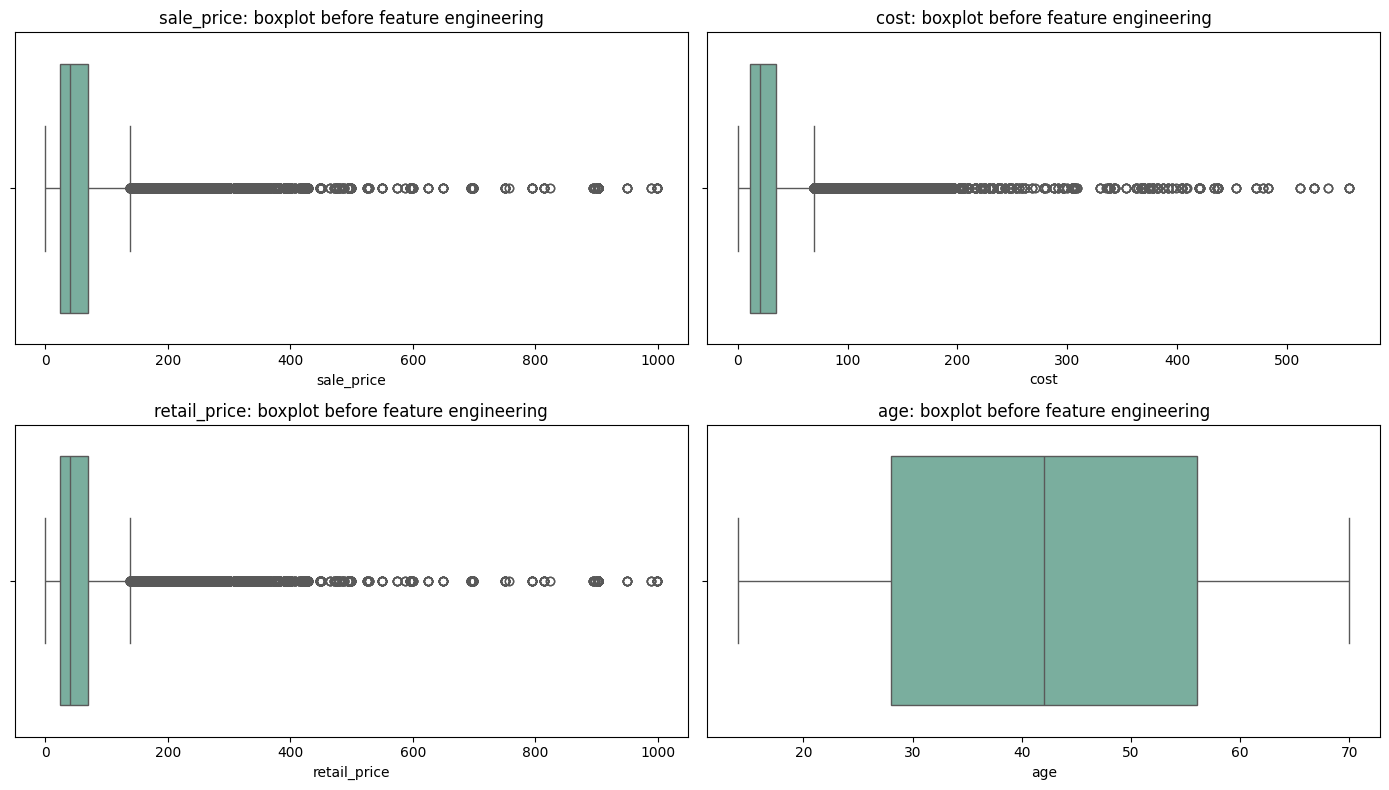

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_cols = [c for c in ['sale_price', 'cost', 'retail_price', 'age'] if c in orders.columns]
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(x=orders[col], ax=axes[i], color='#72B6A1')
    axes[i].set_title(f'{col}: boxplot before feature engineering')

for j in range(len(plot_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


eda

In [94]:
# Производные признаки по транзакциям и логистике.
orders_eda = orders.copy()

orders_eda['order_date'] = orders_eda['created_at'].dt.date
orders_eda['order_month'] = orders_eda['created_at'].dt.to_period('M').astype(str)
orders_eda['order_week'] = orders_eda['created_at'].dt.isocalendar().week.astype('int64')
orders_eda['day_of_week'] = orders_eda['created_at'].dt.day_name()
orders_eda['hour'] = orders_eda['created_at'].dt.hour

orders_eda['line_revenue'] = orders_eda['sale_price'] * orders_eda['num_of_item']
orders_eda['line_cost'] = orders_eda['cost'] * orders_eda['num_of_item']
orders_eda['line_profit'] = orders_eda['line_revenue'] - orders_eda['line_cost']
orders_eda['margin_ratio'] = np.where(orders_eda['line_revenue'] > 0, orders_eda['line_profit'] / orders_eda['line_revenue'], np.nan)

orders_eda['is_returned'] = orders_eda['returned_at'].notna().astype(int)
orders_eda['is_shipped'] = orders_eda['shipped_at'].notna().astype(int)
orders_eda['is_delivered'] = orders_eda['delivered_at'].notna().astype(int)
orders_eda['is_cancelled'] = orders_eda['status'].astype(str).str.lower().str.contains('cancel', na=False).astype(int)

orders_eda['shipping_delay_days'] = (orders_eda['shipped_at'] - orders_eda['created_at']).dt.total_seconds() / 86400
orders_eda['delivery_days'] = (orders_eda['delivered_at'] - orders_eda['created_at']).dt.total_seconds() / 86400
orders_eda['delivery_gap_days'] = (orders_eda['delivered_at'] - orders_eda['shipped_at']).dt.total_seconds() / 86400
orders_eda['return_days'] = (orders_eda['returned_at'] - orders_eda['created_at']).dt.total_seconds() / 86400

for col in ['shipping_delay_days', 'delivery_days', 'delivery_gap_days', 'return_days']:
    orders_eda.loc[orders_eda[col] < 0, col] = np.nan

display(orders_eda[['line_revenue', 'line_cost', 'line_profit', 'margin_ratio', 'shipping_delay_days', 'delivery_days', 'return_days']].describe().T)

,count,mean,std,min,25%,50%,75%,max
line_revenue,181926.0,113.208752,156.094453,0.020000,34.000000,65.760002,132.660004,3996.000000
line_cost,181926.0,54.480559,72.886608,0.008300,16.419975,32.045000,64.500000,2149.140006
line_profit,181926.0,58.728193,85.220451,0.011700,16.896000,32.942640,67.469333,2377.619995
margin_ratio,181926.0,0.510378,0.072499,0.330000,0.453000,0.512000,0.568000,0.669000
shipping_delay_days,118018.0,1.497028,0.867430,0.000000,0.747917,1.494444,2.246528,2.999306
delivery_days,63375.0,3.998594,1.683320,0.036806,2.732639,3.997222,5.256250,7.981250
return_days,18058.0,5.490505,1.906398,0.177778,4.115278,5.540278,6.859722,10.656944


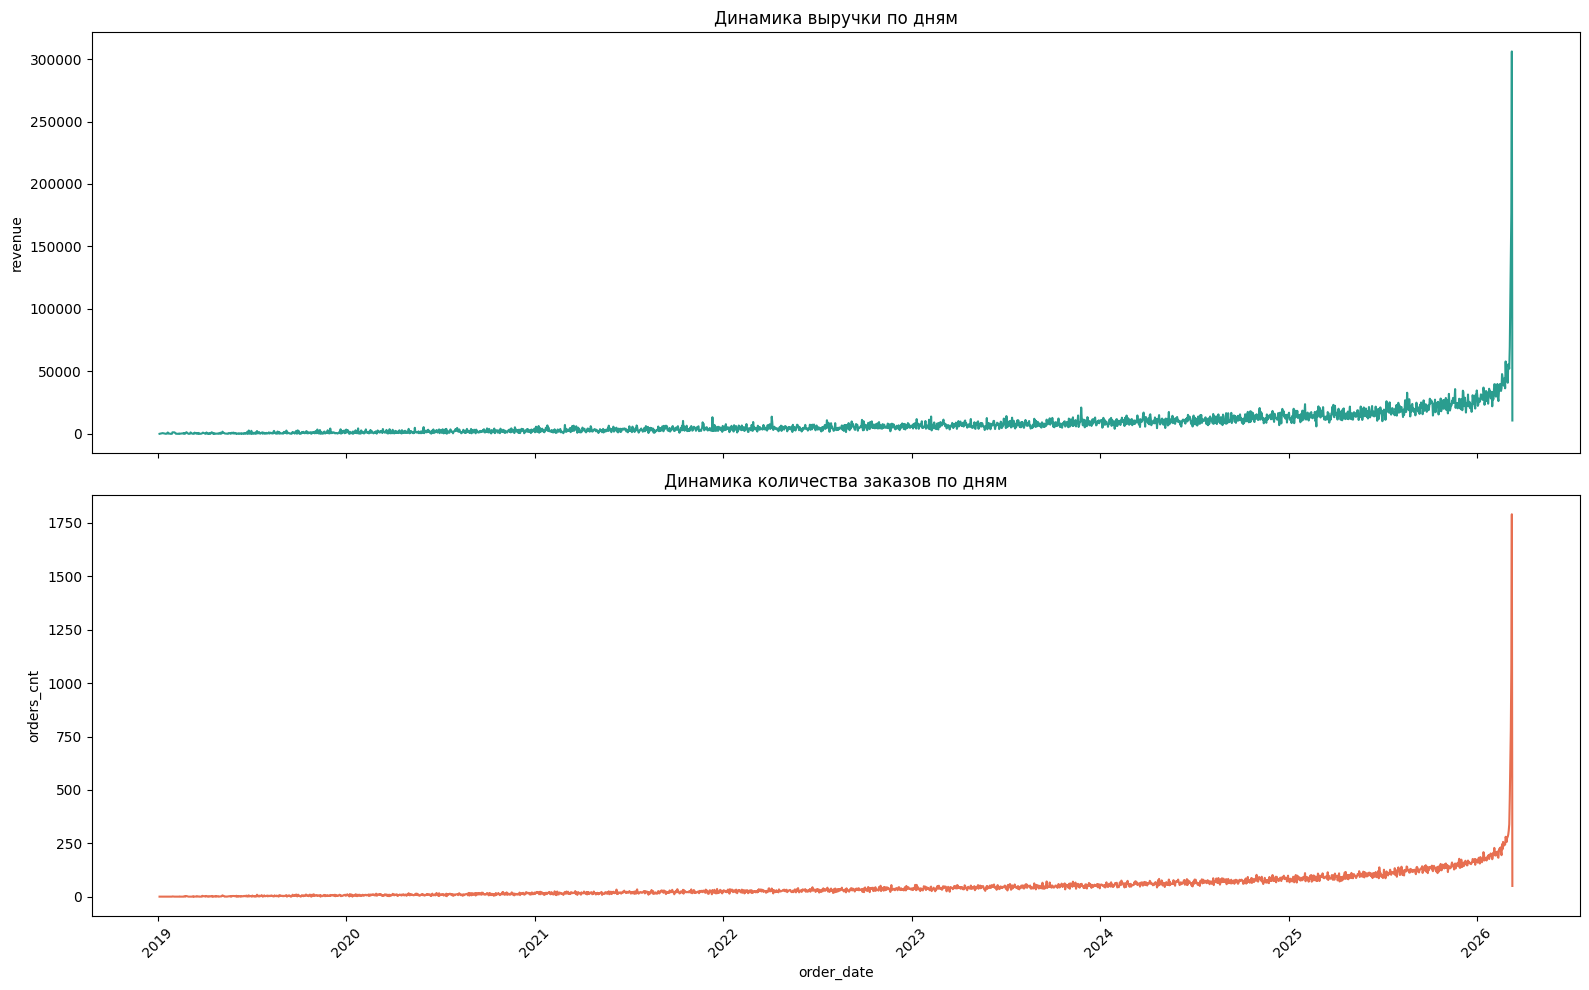

,order_date,revenue,profit,orders_cnt,users_cnt,items_cnt
0,2019-01-04,22.889999,10.025820,1,1,1
1,2019-01-10,572.719994,306.745836,1,1,16
2,2019-01-16,39.990002,20.154961,1,1,1
3,2019-01-18,149.820000,86.048300,1,1,4
4,2019-01-20,1091.959999,654.224277,1,1,16


In [95]:
# Динамика продаж по дням.
daily_sales = orders_eda.groupby('order_date', as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    profit=('line_profit', 'sum'),
    orders_cnt=('order_id', 'nunique'),
    users_cnt=('user_id', 'nunique'),
    items_cnt=('num_of_item', 'sum')
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
sns.lineplot(data=daily_sales, x='order_date', y='revenue', ax=axes[0], color='#2A9D8F')
axes[0].set_title('Динамика выручки по дням')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=daily_sales, x='order_date', y='orders_cnt', ax=axes[1], color='#E76F51')
axes[1].set_title('Динамика количества заказов по дням')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(daily_sales.head())

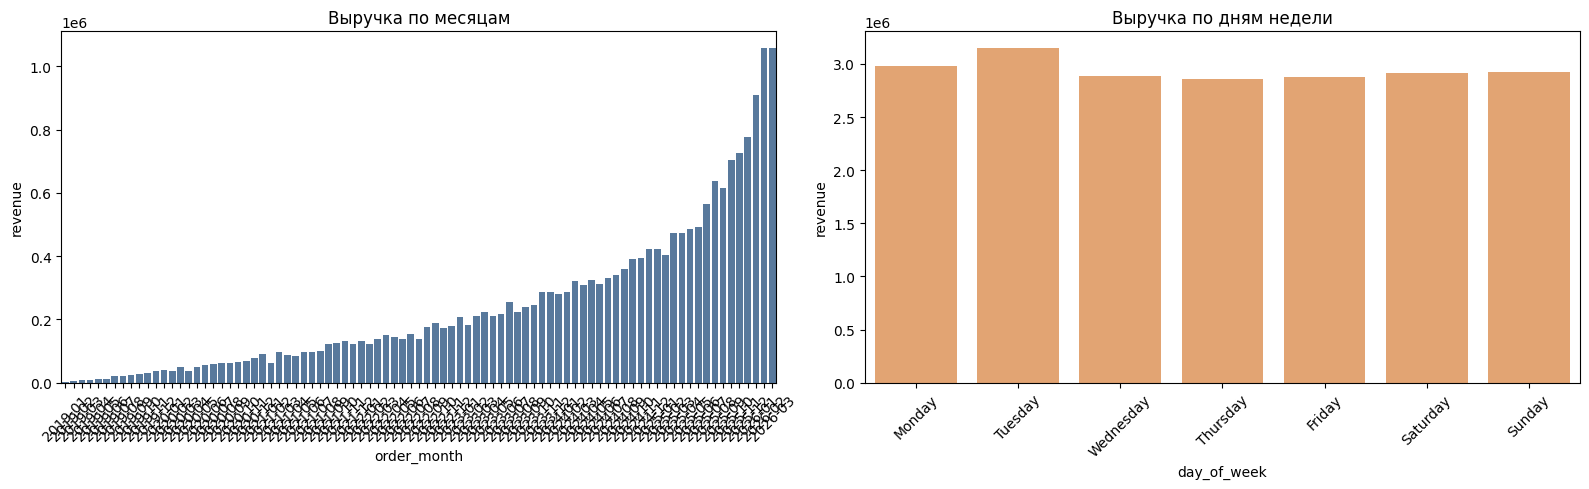

,order_month,revenue,profit,orders_cnt,users_cnt
0,2019-01,3.574760e+03,1986.640277,11,11
1,2019-02,4.951590e+03,2582.107152,23,23
2,2019-03,7.602300e+03,3827.261458,38,38
3,2019-04,8.698070e+03,4459.453675,58,57
4,2019-05,1.156919e+04,6048.355179,68,68
...,...,...,...,...,...
82,2025-11,7.267205e+05,376103.748598,4352,4181
83,2025-12,7.763107e+05,402555.106999,4937,4692
84,2026-01,9.087488e+05,470921.898849,5584,5241
85,2026-02,1.056707e+06,547570.191998,6218,5627


In [71]:
# Динамика по месяцам и сезонные паттерны.
monthly_sales = orders_eda.groupby('order_month', as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    profit=('line_profit', 'sum'),
    orders_cnt=('order_id', 'nunique'),
    users_cnt=('user_id', 'nunique')
)

weekday_sales = orders_eda.groupby('day_of_week', as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    orders_cnt=('order_id', 'nunique')
)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales['day_of_week'] = pd.Categorical(weekday_sales['day_of_week'], categories=weekday_order, ordered=True)
weekday_sales = weekday_sales.sort_values('day_of_week')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=monthly_sales, x='order_month', y='revenue', ax=axes[0], color='#4C78A8')
axes[0].set_title('Выручка по месяцам')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=weekday_sales, x='day_of_week', y='revenue', ax=axes[1], color='#F4A261')
axes[1].set_title('Выручка по дням недели')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(monthly_sales)

,category,revenue,profit,orders_cnt,return_rate,avg_price
11,Outerwear & Coats,2.491400e+06,1.383528e+06,8850,0.097566,145.438666
7,Jeans,2.383560e+06,1.107762e+06,12231,0.098007,99.091777
22,Sweaters,1.587250e+06,8.211423e+05,10590,0.096309,76.009808
21,Suits & Sport Coats,1.256122e+06,7.519372e+05,5065,0.105000,127.131259
5,Fashion Hoodies & Sweatshirts,1.229965e+06,5.910001e+05,11491,0.098665,54.669819
23,Swim,1.222738e+06,5.977572e+05,11086,0.104446,56.720077
17,Sleep & Lounge,1.070311e+06,5.559821e+05,11069,0.103663,48.886621
15,Shorts,1.005746e+06,5.017206e+05,11068,0.095126,46.307230
24,Tops & Tees,9.527124e+05,4.191670e+05,11595,0.099549,41.603781
6,Intimates,8.575819e+05,4.012857e+05,12498,0.097956,33.763800


,product_id,product_name,revenue,profit,orders_cnt,return_rate
23914,23989,The North Face Freedom Mens Ski Pants 2013,24381.0,14409.170955,11,0.181818
24372,24447,Darla,17982.0,10699.289979,11,0.090909
22738,22812,Quiksilver Men's Rockefeller Walkshort,17157.0,8183.888999,9,0.000000
18588,18656,JORDAN DURASHEEN SHORT MENS 404309-109,17157.0,10122.629965,7,0.142857
8389,8429,The North Face Women's S-XL Oso Jacket,16254.0,9443.574004,8,0.125000
24353,24428,The North Face Apex Bionic Mens Soft Shell Ski...,16254.0,8695.889972,12,0.083333
23978,24053,The North Face Denali Down Mens Jacket 2013,15351.0,7936.466957,8,0.000000
5190,5213,Catherine Malandrino Women's Skinny Stretch Le...,15215.0,7835.725037,6,0.166667
23579,23654,The North Face Apex Bionic Soft Shell Jacket -...,14448.0,8639.903963,7,0.285714
23471,23546,Alpha Industries Rip Stop Short,13986.0,7230.762013,6,0.166667


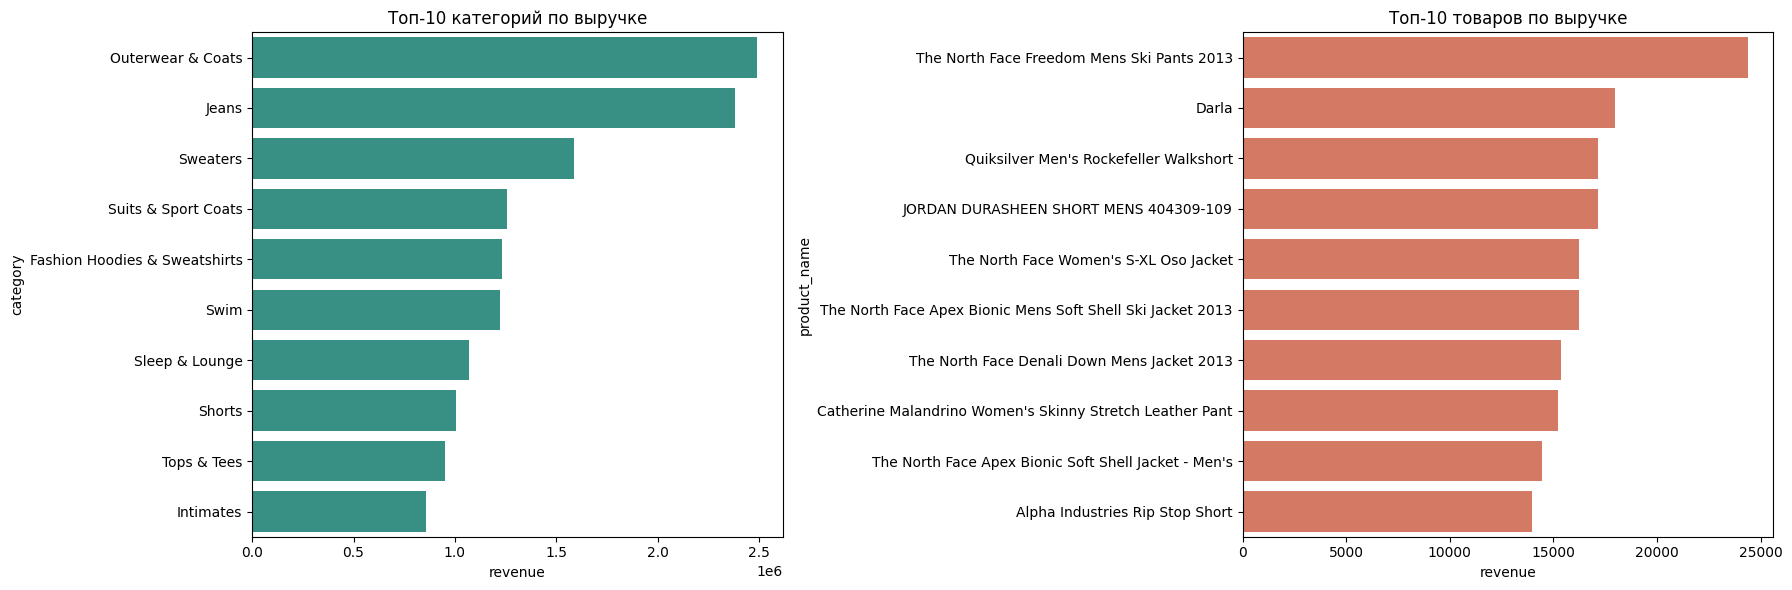

In [72]:
# Категории и товары.
top_categories = orders_eda.groupby('category', as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    profit=('line_profit', 'sum'),
    orders_cnt=('order_id', 'nunique'),
    return_rate=('is_returned', 'mean'),
    avg_price=('sale_price', 'mean')
).sort_values('revenue', ascending=False)

top_products = orders_eda.groupby(['product_id', 'product_name'], as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    profit=('line_profit', 'sum'),
    orders_cnt=('order_id', 'nunique'),
    return_rate=('is_returned', 'mean')
).sort_values('revenue', ascending=False).head(15)

display(top_categories.head(15))
display(top_products.head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=top_categories.head(10), y='category', x='revenue', ax=axes[0], color='#2A9D8F')
axes[0].set_title('Топ-10 категорий по выручке')

sns.barplot(data=top_products.head(10), y='product_name', x='revenue', ax=axes[1], color='#E76F51')
axes[1].set_title('Топ-10 товаров по выручке')

plt.tight_layout()
plt.show()

,category,orders_cnt,returned_items,return_rate,avg_delivery_days,revenue
8,Jumpsuits & Rompers,906,104,0.113910,3.971994,7.742774e+04
13,Pants & Capris,3426,383,0.110121,4.023279,3.828363e+05
19,Socks & Hosiery,3694,401,0.106507,3.984426,1.183422e+05
21,Suits & Sport Coats,5065,546,0.105000,4.053503,1.256122e+06
23,Swim,11086,1191,0.104446,3.951140,1.222738e+06
17,Sleep & Lounge,11069,1180,0.103663,4.019863,1.070311e+06
25,Underwear,7364,790,0.103254,3.971831,3.998194e+05
2,Blazers & Jackets,3234,334,0.101705,3.979407,5.809921e+05
18,Socks,6131,638,0.100981,4.028311,2.352262e+05
14,Plus,4195,432,0.100817,4.010949,3.117184e+05


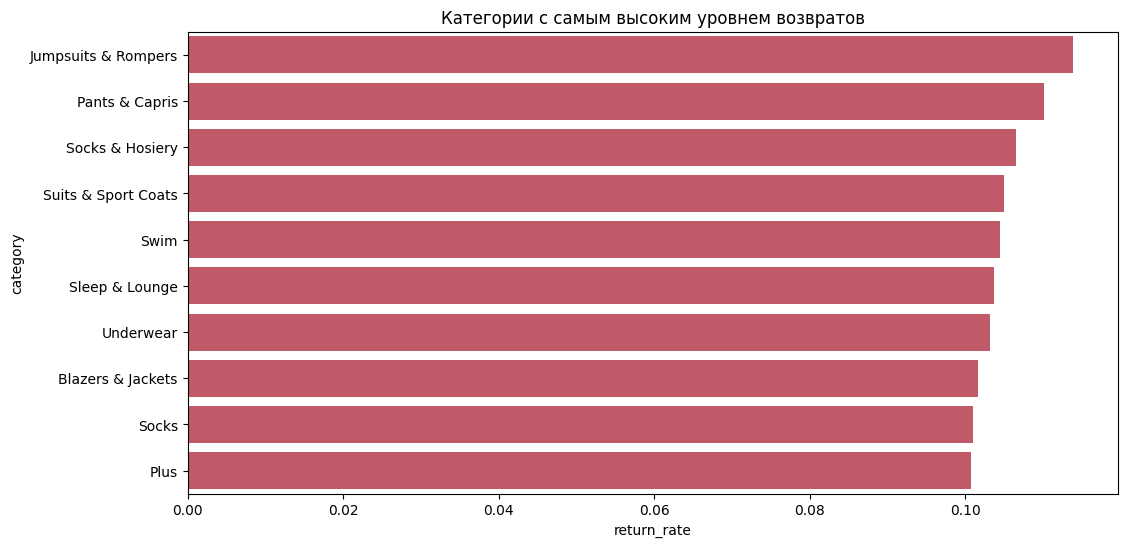

In [73]:
# Возвраты и проблемные категории.
category_returns = orders_eda.groupby('category', as_index=False).agg(
    orders_cnt=('order_id', 'nunique'),
    returned_items=('is_returned', 'sum'),
    return_rate=('is_returned', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    revenue=('line_revenue', 'sum')
)
category_returns = category_returns[category_returns['orders_cnt'] >= 30].sort_values('return_rate', ascending=False)

display(category_returns.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(data=category_returns.head(10), y='category', x='return_rate', color='#D1495B')
plt.title('Категории с самым высоким уровнем возвратов')
plt.show()

,mean,median
shipping_delay_days,1.497028,1.494444
delivery_days,3.998594,3.997222
delivery_gap_days,2.504978,2.501389
return_days,5.490505,5.540278


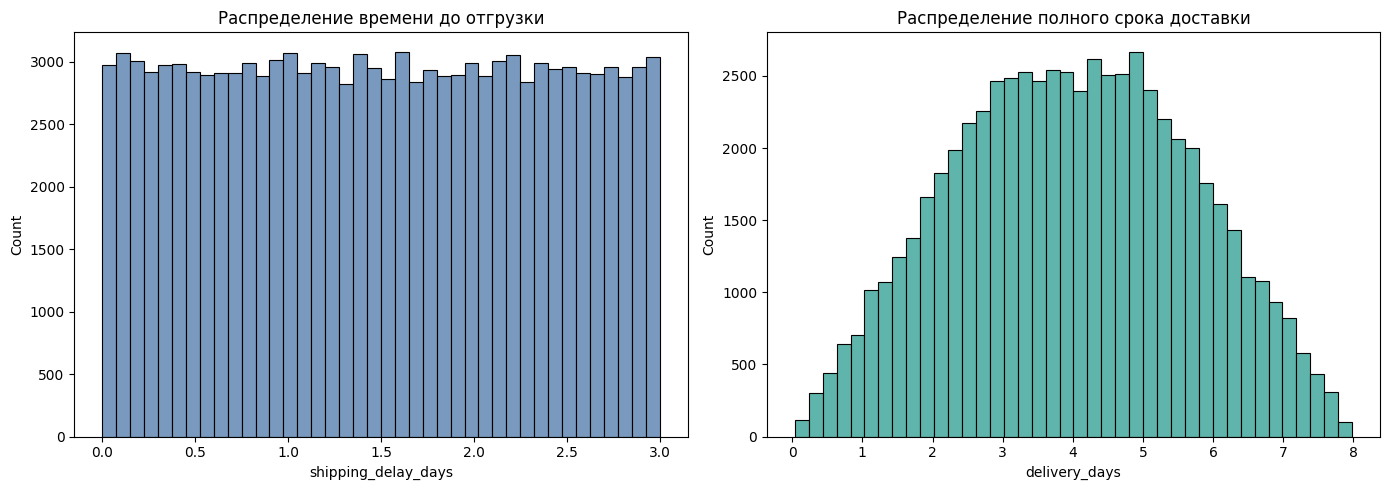

In [74]:
# Логистика.
logistics_summary = orders_eda.agg({
    'shipping_delay_days': ['mean', 'median'],
    'delivery_days': ['mean', 'median'],
    'delivery_gap_days': ['mean', 'median'],
    'return_days': ['mean', 'median']
}).T
logistics_summary.columns = ['mean', 'median']
display(logistics_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(orders_eda['shipping_delay_days'].dropna(), bins=40, ax=axes[0], color='#4C78A8')
axes[0].set_title('Распределение времени до отгрузки')

sns.histplot(orders_eda['delivery_days'].dropna(), bins=40, ax=axes[1], color='#2A9D8F')
axes[1].set_title('Распределение полного срока доставки')

plt.tight_layout()
plt.show()

,state,city,revenue,profit,users_cnt,orders_cnt,avg_delivery_days
7205,Seoul,Seoul,287603.040430,148587.991839,1231,1866,3.991418
5357,New York,New York,175805.690104,91477.763715,652,1006,3.979274
7974,Tokyo,Tokyo,167278.420063,86505.236331,693,1077,3.903926
658,Bahia,Salvador,127357.720159,65994.106521,413,654,4.074681
970,Busan,Busan,116997.520263,60810.035588,407,651,3.717627
2235,England,London,107238.860047,56071.943435,412,641,3.834445
7629,São Paulo,São Paulo,105284.200040,53930.852125,400,627,4.003848
5269,New South Wales,Sydney,91040.850074,46717.230307,337,550,3.992232
1983,Distrito Federal,Brasília,89696.570110,46165.426005,344,530,4.017936
1890,Comunidad de Madrid,Madrid,87755.520101,45153.037647,334,509,4.126683


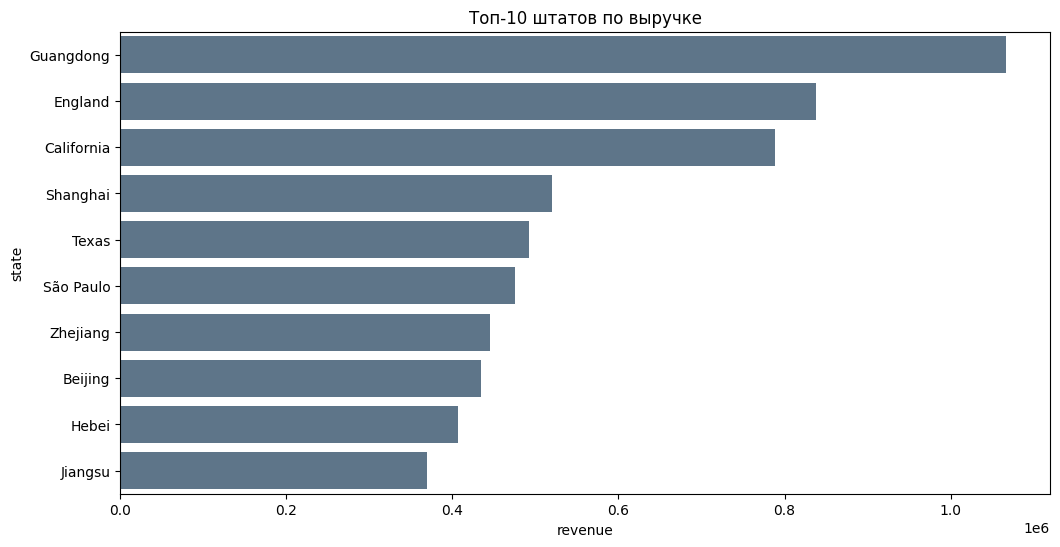

In [75]:
# География продаж.
geo_sales = orders_eda.groupby(['state', 'city'], as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    profit=('line_profit', 'sum'),
    users_cnt=('user_id', 'nunique'),
    orders_cnt=('order_id', 'nunique'),
    avg_delivery_days=('delivery_days', 'mean')
).sort_values('revenue', ascending=False)

state_sales = orders_eda.groupby('state', as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    users_cnt=('user_id', 'nunique'),
    avg_delivery_days=('delivery_days', 'mean')
).sort_values('revenue', ascending=False)

display(geo_sales.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales.head(10), y='state', x='revenue', color='#577590')
plt.title('Топ-10 штатов по выручке')
plt.show()

,traffic_source,revenue,users_cnt,orders_cnt,avg_order_value
4,Search,1.442600e+07,56029,87636,113.225949
3,Organic,3.139495e+06,12020,18758,114.584284
2,Facebook,1.195415e+06,4766,7404,111.087767
1,Email,9.846564e+05,3937,6141,111.059824
0,Display,8.500438e+05,3269,5146,113.475349


,age_group,revenue,users_cnt,avg_order_value
0,14-24,3.420400e+06,13370,112.628019
1,25-34,3.517033e+06,13555,114.602400
2,35-44,4.180454e+06,16246,113.107531
3,45-54,3.491278e+06,13458,113.711288
4,55-64,3.551485e+06,13797,112.910435
5,65+,2.118935e+06,8266,112.643378


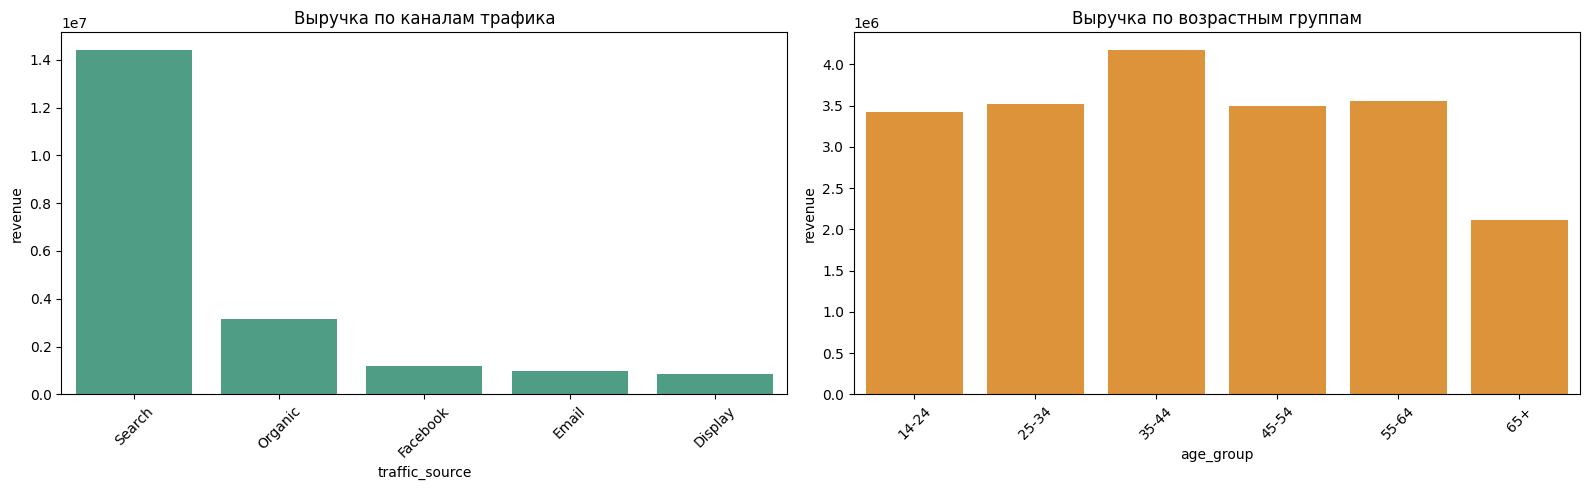

In [76]:
# Клиенты и источники трафика.
traffic_sales = orders_eda.groupby('traffic_source', as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    users_cnt=('user_id', 'nunique'),
    orders_cnt=('order_id', 'nunique'),
    avg_order_value=('line_revenue', 'mean')
).sort_values('revenue', ascending=False)

gender_sales = orders_eda.groupby('gender', as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    users_cnt=('user_id', 'nunique'),
    avg_order_value=('line_revenue', 'mean')
)

age_bins = [14, 24, 34, 44, 54, 64, 100]
age_labels = ['14-24', '25-34', '35-44', '45-54', '55-64', '65+']
orders_eda['age_group'] = pd.cut(orders_eda['age'], bins=age_bins, labels=age_labels, right=True)
age_sales = orders_eda.groupby('age_group', as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    users_cnt=('user_id', 'nunique'),
    avg_order_value=('line_revenue', 'mean')
)

display(traffic_sales)
display(age_sales)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=traffic_sales, x='traffic_source', y='revenue', ax=axes[0], color='#43AA8B')
axes[0].set_title('Выручка по каналам трафика')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=age_sales, x='age_group', y='revenue', ax=axes[1], color='#F8961E')
axes[1].set_title('Выручка по возрастным группам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

,event_type,events_cnt,users_cnt
4,product,846396,80021
2,department,596365,80021
1,cart,595991,80021
5,purchase,181926,80021
0,cancel,124680,0
3,home,87304,62967


,browser,events_cnt,users_cnt
0,Chrome,1218890,55775
4,Safari,486587,29079
1,Firefox,486499,28999
2,IE,120387,8481
3,Other,120299,8429


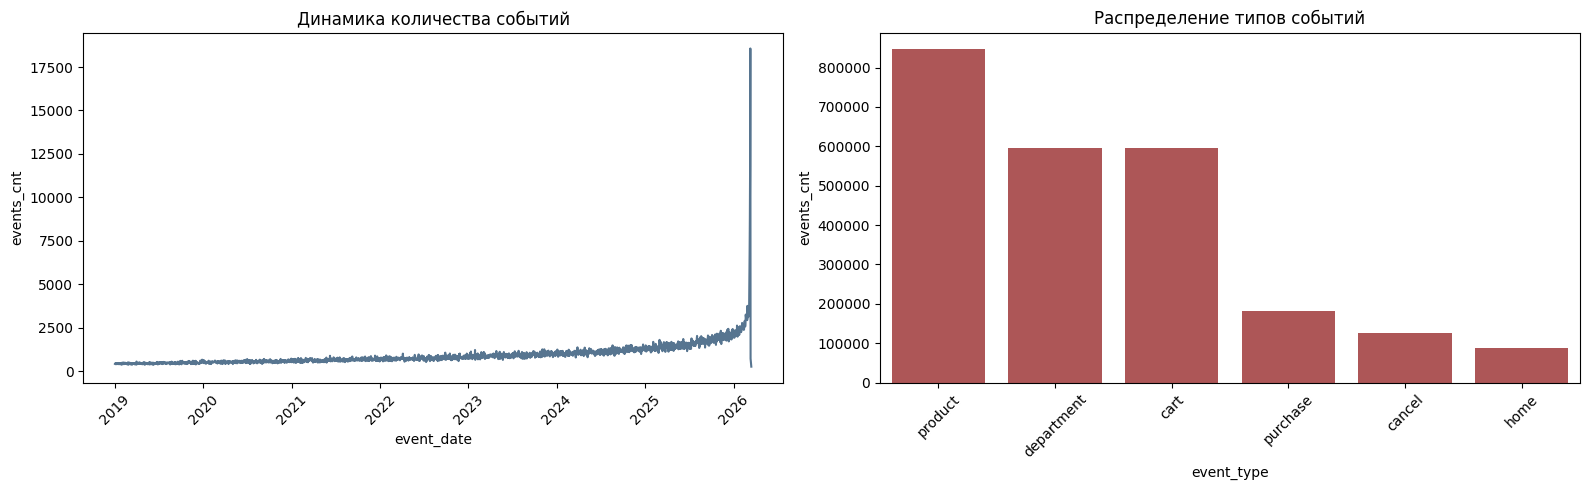

In [77]:
# Базовый анализ событий.
events_eda = events.copy()
events_eda = events_eda.dropna(subset=['created_at'])
events_eda['event_date'] = events_eda['created_at'].dt.date
events_eda['event_month'] = events_eda['created_at'].dt.to_period('M').astype(str)

events_daily = events_eda.groupby('event_date', as_index=False).agg(
    events_cnt=('id', 'count'),
    users_cnt=('user_id', 'nunique'),
    sessions_cnt=('session_id', 'nunique')
)

event_type_stats = events_eda.groupby('event_type', as_index=False).agg(
    events_cnt=('id', 'count'),
    users_cnt=('user_id', 'nunique')
).sort_values('events_cnt', ascending=False)

browser_stats = events_eda.groupby('browser', as_index=False).agg(
    events_cnt=('id', 'count'),
    users_cnt=('user_id', 'nunique')
).sort_values('events_cnt', ascending=False)

display(event_type_stats)
display(browser_stats.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=events_daily, x='event_date', y='events_cnt', ax=axes[0], color='#577590')
axes[0].set_title('Динамика количества событий')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=event_type_stats, x='event_type', y='events_cnt', ax=axes[1], color='#BC4749')
axes[1].set_title('Распределение типов событий')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [78]:
# Итоговые витрины для следующих этапов.
sales_mart = daily_sales.copy()
category_mart = top_categories.copy()
geo_mart = geo_sales.copy()
events_mart = events_daily.copy()

print('sales_mart:', sales_mart.shape)
print('category_mart:', category_mart.shape)
print('geo_mart:', geo_mart.shape)
print('events_mart:', events_mart.shape)


sales_mart: (2571, 6)
category_mart: (26, 6)
geo_mart: (8918, 7)
events_mart: (2629, 4)


In [79]:
# NLP-фичи из текстовых отзывов.
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

orders_eda['review_text'] = orders_eda['customer_review'].fillna('Unknown').astype(str)
orders_eda['review_text_lower'] = orders_eda['review_text'].str.lower()

def clean_review_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

orders_eda['review_text_clean'] = orders_eda['review_text'].apply(clean_review_text)
orders_eda['review_char_len'] = orders_eda['review_text'].str.len()
orders_eda['review_word_count'] = orders_eda['review_text_clean'].str.split().str.len()
orders_eda['review_unique_word_count'] = orders_eda['review_text_clean'].apply(lambda x: len(set(x.split())) if x else 0)
orders_eda['review_exclamation_count'] = orders_eda['review_text'].str.count('!')
orders_eda['review_question_count'] = orders_eda['review_text'].str.count('\?')
orders_eda['has_review'] = orders_eda['review_text'].ne('Unknown').astype(int)

positive_words = {
    'good', 'great', 'excellent', 'amazing', 'perfect', 'love', 'loved', 'happy',
    'comfortable', 'durable', 'nice', 'solid', 'recommend', 'satisfied', 'works'
}
negative_words = {
    'bad', 'poor', 'terrible', 'awful', 'disappointed', 'broken', 'late', 'return',
    'cheap', 'worst', 'hate', 'problem', 'issue', 'damaged', 'small', 'big', 'fit'
}

def count_lexicon_words(text, lexicon):
    tokens = text.split()
    return sum(token in lexicon for token in tokens)

orders_eda['positive_word_count'] = orders_eda['review_text_clean'].apply(lambda x: count_lexicon_words(x, positive_words))
orders_eda['negative_word_count'] = orders_eda['review_text_clean'].apply(lambda x: count_lexicon_words(x, negative_words))
orders_eda['review_sentiment_score'] = orders_eda['positive_word_count'] - orders_eda['negative_word_count']
orders_eda['review_negative_flag'] = (orders_eda['negative_word_count'] > orders_eda['positive_word_count']).astype(int)
orders_eda['review_positive_flag'] = (orders_eda['positive_word_count'] > orders_eda['negative_word_count']).astype(int)

display(orders_eda[[
    'review_char_len', 'review_word_count', 'review_unique_word_count',
    'positive_word_count', 'negative_word_count', 'review_sentiment_score'
]].describe().T)


,count,mean,std,min,25%,50%,75%,max
review_char_len,181926.0,120.585568,23.329206,52.0,104.0,117.0,135.0,327.0
review_word_count,181926.0,20.948419,4.283540,8.0,18.0,21.0,24.0,57.0
review_unique_word_count,181926.0,20.432462,4.065618,8.0,18.0,20.0,23.0,52.0
positive_word_count,181926.0,1.224047,0.879760,0.0,0.0,1.0,2.0,4.0
negative_word_count,181926.0,0.168563,0.399263,0.0,0.0,0.0,0.0,3.0
review_sentiment_score,181926.0,1.055484,1.081888,-3.0,0.0,1.0,2.0,4.0


,word,freq
0,quality,9983
1,expected,8779
2,returning,8749
3,men,7018
4,fit,6764
5,better,4428
6,experience,4427
7,poor,4426
8,customer,4426
9,completely,4396


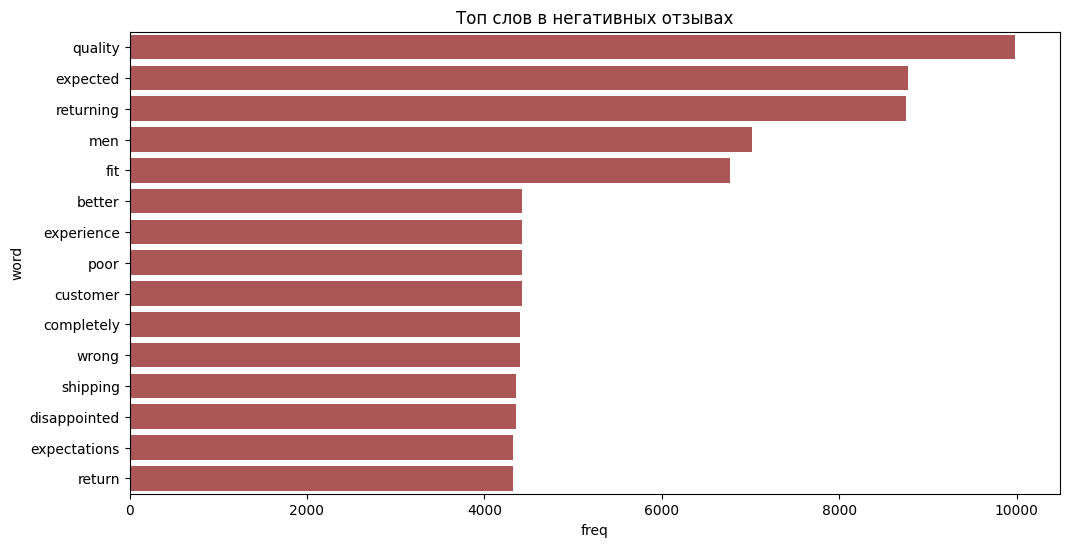

In [80]:
# Частые слова в негативных отзывах.
neg_reviews = orders_eda.loc[orders_eda['review_negative_flag'] == 1, 'review_text_clean']
tokens = []
for text in neg_reviews:
    for token in text.split():
        if len(token) > 2 and token not in ENGLISH_STOP_WORDS:
            tokens.append(token)

neg_word_freq = pd.DataFrame(Counter(tokens).most_common(20), columns=['word', 'freq'])
display(neg_word_freq)

plt.figure(figsize=(12, 6))
sns.barplot(data=neg_word_freq.head(15), y='word', x='freq', color='#BC4749')
plt.title('Топ слов в негативных отзывах')
plt.show()


In [81]:
# Агрегаты NLP-признаков по товарам.
product_review_features = orders_eda.groupby(['product_id', 'product_name'], as_index=False).agg(
    review_count=('review_text', 'count'),
    avg_review_len=('review_word_count', 'mean'),
    negative_review_rate=('review_negative_flag', 'mean'),
    positive_review_rate=('review_positive_flag', 'mean'),
    avg_sentiment_score=('review_sentiment_score', 'mean'),
    return_rate=('is_returned', 'mean'),
    revenue=('line_revenue', 'sum')
).sort_values('negative_review_rate', ascending=False)

display(product_review_features.head(15))


,product_id,product_name,review_count,avg_review_len,negative_review_rate,positive_review_rate,avg_sentiment_score,return_rate,revenue
7687,7724,Mango Women's Biker BouclÃ© Jacket - Flu,1,14.000000,1.0,0.0,-1.00,1.0,239.960007
7656,7692,G-Star Women's Cruise Blazer,1,24.000000,1.0,0.0,-1.00,1.0,122.570000
6290,6319,American Apparel The Disco Short,1,12.000000,1.0,0.0,-1.00,1.0,104.000000
10435,10484,Goddess Women's Keira Nursing Bra,1,18.000000,1.0,0.0,-1.00,1.0,48.000000
11275,11327,Kendall Scoop Strappy Tank by Yummie Tummie #Y...,1,25.000000,1.0,0.0,-1.00,1.0,113.419998
25625,25705,Diesel Men's Boxer Shorts,1,12.000000,1.0,0.0,-1.00,1.0,56.000000
1048,1052,Magaschoni Women's 100% Cashmere Cable Sweater...,3,18.000000,1.0,0.0,-1.00,1.0,1764.000000
7391,7426,Karen Kane Women's Scallop Lace Pencil Skirt,3,18.666667,1.0,0.0,-1.00,1.0,472.000000
25267,25345,Darn Tough - 1/4 Sock Merino Mesh,1,18.000000,1.0,0.0,-1.00,1.0,34.000000
20591,20663,Dickies Men's Loose Straight Fit Five Pocket Jean,2,27.000000,1.0,0.0,-1.00,0.0,211.900005


In [82]:
# Агрегаты NLP-признаков по пользователям для будущей churn-модели.
user_review_features = orders_eda.groupby('user_id', as_index=False).agg(
    user_review_count=('review_text', 'count'),
    user_avg_review_len=('review_word_count', 'mean'),
    user_negative_review_rate=('review_negative_flag', 'mean'),
    user_positive_review_rate=('review_positive_flag', 'mean'),
    user_avg_sentiment_score=('review_sentiment_score', 'mean')
)

display(user_review_features.head())
print('user_review_features:', user_review_features.shape)
print('product_review_features:', product_review_features.shape)


,user_id,user_review_count,user_avg_review_len,user_negative_review_rate,user_positive_review_rate,user_avg_sentiment_score
0,1,1,23.00,0.0,1.0,1.0
1,2,4,18.75,0.0,0.5,1.0
2,3,2,17.50,1.0,0.0,-1.0
3,4,1,21.00,0.0,1.0,2.0
4,6,1,27.00,0.0,1.0,2.0


user_review_features: (80021, 6)
product_review_features: (29039, 9)


In [83]:
product_review_features_filtered = product_review_features[
    product_review_features['review_count'] >= 10
].copy()

display(
    product_review_features_filtered
    .sort_values(['negative_review_rate', 'review_count'], ascending=[False, False])
    .head(20)
)


,product_id,product_name,review_count,avg_review_len,negative_review_rate,positive_review_rate,avg_sentiment_score,return_rate,revenue
21380,21453,Greystone Loose Fit Jeans In Blue or Black #560A,11,23.363636,0.727273,0.181818,-0.636364,0.090909,1631.849930
20533,20605,Levi's Men's 505 Big & Tall Straight Fit Jean,11,21.909091,0.727273,0.000000,-1.454545,0.272727,1564.000000
21508,21582,Big Star Men's Pioneer Bootcut Fit Jean in Trace,10,23.200000,0.700000,0.000000,-1.100000,0.100000,1372.000000
26817,26897,Harbor Bay Big & Tall Cotton Fleece Robe,10,21.400000,0.700000,0.200000,-0.700000,0.200000,1462.000000
22279,22353,Tommy Hilfiger Men's Trim Fit Flat Front Pant,10,21.700000,0.700000,0.200000,-0.600000,0.100000,1002.539993
16738,16805,Polo Ralph Lauren Men's Custom Fit Crossed Fla...,10,23.200000,0.700000,0.000000,-1.700000,0.400000,1425.000000
21813,21887,Perry Ellis Men's Railroad City/Modern-Fit Str...,14,25.071429,0.642857,0.285714,-0.571429,0.214286,1559.610065
7740,7777,Anna-Kaci S/M Fit Black Classic Professional B...,11,24.545455,0.636364,0.272727,-0.727273,0.363636,838.099989
20734,20806,Rocawear Men's R Plus Regular Fit Core Jean,11,19.363636,0.636364,0.363636,-0.454545,0.181818,1130.500000
20596,20668,Levi's Men's 505 Classic Straight Fit Twill Pant,10,21.800000,0.600000,0.200000,-0.800000,0.400000,941.999969


In [84]:
!pip install catboost

In [86]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from catboost import CatBoostClassifier

In [ ]:
orders

In [105]:
CHURN_GAP_DAYS = 120
FEATURE_WINDOW_DAYS = 180
SNAPSHOT_FREQ = 'MS'

max_order_date = orders_eda['created_at'].max().normalize()
min_snapshot_date = orders_eda['created_at'].min().normalize() + pd.Timedelta(days=FEATURE_WINDOW_DAYS)
max_snapshot_date = max_order_date - pd.Timedelta(days=CHURN_GAP_DAYS)

snapshot_dates = pd.date_range(min_snapshot_date, max_snapshot_date, freq=SNAPSHOT_FREQ)
snapshot_dates = snapshot_dates[-12:]

print('snapshot_dates from', snapshot_dates.min(), 'to', snapshot_dates.max())
print('n_snapshots:', len(snapshot_dates))

snapshot_dates from 2024-12-01 00:00:00+00:00 to 2025-11-01 00:00:00+00:00
n_snapshots: 12


In [100]:
# Функция сборки snapshot-фичей на дату as_of_date.
def build_snapshot_features(orders_df, events_df, as_of_date, feature_window_days=180, churn_gap_days=90):
    window_start = as_of_date - pd.Timedelta(days=feature_window_days)
    future_end = as_of_date + pd.Timedelta(days=churn_gap_days)

    hist_orders = orders_df[(orders_df['created_at'] >= window_start) & (orders_df['created_at'] < as_of_date)].copy()
    future_orders = orders_df[(orders_df['created_at'] >= as_of_date) & (orders_df['created_at'] < future_end)].copy()

    if hist_orders.empty:
        return pd.DataFrame()

    customer_features = hist_orders.groupby('user_id', as_index=False).agg(
        first_order_in_window=('created_at', 'min'),
        last_order_in_window=('created_at', 'max'),
        orders_cnt=('order_id', 'nunique'),
        items_cnt=('num_of_item', 'sum'),
        total_revenue=('line_revenue', 'sum'),
        total_profit=('line_profit', 'sum'),
        avg_order_value=('line_revenue', 'mean'),
        avg_items_per_order_line=('num_of_item', 'mean'),
        avg_margin_ratio=('margin_ratio', 'mean'),
        return_rate=('is_returned', 'mean'),
        cancel_rate=('is_cancelled', 'mean'),
        shipped_rate=('is_shipped', 'mean'),
        delivered_rate=('is_delivered', 'mean'),
        avg_shipping_delay_days=('shipping_delay_days', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_return_days=('return_days', 'mean'),
        unique_categories=('category', 'nunique'),
        unique_products=('product_id', 'nunique'),
        unique_brands=('brand', 'nunique'),
        favorite_category=('category', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
        favorite_brand=('brand', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
        traffic_source=('traffic_source', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
        gender=('gender', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
        state=('state', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
        age=('age', 'median'),
        is_loyal=('is_loyal', 'max')
    )

    customer_features['recency_days'] = (as_of_date - customer_features['last_order_in_window']).dt.days
    customer_features['tenure_days_in_window'] = (customer_features['last_order_in_window'] - customer_features['first_order_in_window']).dt.days.clip(lower=0)
    customer_features['purchase_frequency_30d'] = customer_features['orders_cnt'] / np.maximum(feature_window_days / 30, 1)

    recent_30 = hist_orders[hist_orders['created_at'] >= as_of_date - pd.Timedelta(days=30)]
    recent_90 = hist_orders[hist_orders['created_at'] >= as_of_date - pd.Timedelta(days=90)]

    recent_30_feats = recent_30.groupby('user_id', as_index=False).agg(
        orders_cnt_30d=('order_id', 'nunique'),
        revenue_30d=('line_revenue', 'sum'),
        return_rate_30d=('is_returned', 'mean')
    )
    recent_90_feats = recent_90.groupby('user_id', as_index=False).agg(
        orders_cnt_90d=('order_id', 'nunique'),
        revenue_90d=('line_revenue', 'sum'),
        return_rate_90d=('is_returned', 'mean')
    )

    customer_features = customer_features.merge(recent_30_feats, on='user_id', how='left')
    customer_features = customer_features.merge(recent_90_feats, on='user_id', how='left')

    required_review_cols = ['review_text', 'review_word_count', 'review_negative_flag', 'review_positive_flag', 'review_sentiment_score']
    if not set(required_review_cols).issubset(hist_orders.columns):
        positive_words_local = {'good', 'great', 'excellent', 'amazing', 'perfect', 'love', 'loved', 'happy', 'comfortable', 'durable', 'nice', 'solid', 'recommend', 'satisfied', 'works'}
        negative_words_local = {'bad', 'poor', 'terrible', 'awful', 'disappointed', 'broken', 'late', 'return', 'cheap', 'worst', 'hate', 'problem', 'issue', 'damaged', 'small', 'big', 'fit'}
        hist_orders['review_text'] = hist_orders['customer_review'].fillna('Unknown').astype(str)
        hist_orders['review_text_clean_tmp'] = hist_orders['review_text'].str.lower().str.replace(r'[^a-z\s]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
        hist_orders['review_word_count'] = hist_orders['review_text_clean_tmp'].str.split().str.len()
        hist_orders['positive_word_count_tmp'] = hist_orders['review_text_clean_tmp'].apply(lambda x: sum(token in positive_words_local for token in x.split()))
        hist_orders['negative_word_count_tmp'] = hist_orders['review_text_clean_tmp'].apply(lambda x: sum(token in negative_words_local for token in x.split()))
        hist_orders['review_sentiment_score'] = hist_orders['positive_word_count_tmp'] - hist_orders['negative_word_count_tmp']
        hist_orders['review_negative_flag'] = (hist_orders['negative_word_count_tmp'] > hist_orders['positive_word_count_tmp']).astype(int)
        hist_orders['review_positive_flag'] = (hist_orders['positive_word_count_tmp'] > hist_orders['negative_word_count_tmp']).astype(int)

    review_features = hist_orders.groupby('user_id', as_index=False).agg(
        user_review_count=('review_text', 'count'),
        user_avg_review_len=('review_word_count', 'mean'),
        user_negative_review_rate=('review_negative_flag', 'mean'),
        user_positive_review_rate=('review_positive_flag', 'mean'),
        user_avg_sentiment_score=('review_sentiment_score', 'mean')
    )
    customer_features = customer_features.merge(review_features, on='user_id', how='left')

    hist_events = events_df[(events_df['created_at'] >= window_start) & (events_df['created_at'] < as_of_date)].copy()
    if not hist_events.empty:
        event_features = hist_events.groupby('user_id', as_index=False).agg(
            events_cnt=('id', 'count'),
            sessions_cnt=('session_id', 'nunique'),
            active_days=('event_date', 'nunique'),
            last_event_at=('created_at', 'max'),
            favorite_event_type=('event_type', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
        )
        event_pivot = pd.crosstab(hist_events['user_id'], hist_events['event_type'])
        event_pivot.columns = [f'event_{str(col).lower()}_cnt' for col in event_pivot.columns]
        event_pivot = event_pivot.reset_index()
        event_features = event_features.merge(event_pivot, on='user_id', how='left')
        event_features['days_since_last_event'] = (as_of_date - event_features['last_event_at']).dt.days
        customer_features = customer_features.merge(event_features, on='user_id', how='left')
    future_activity = future_orders.groupby('user_id', as_index=False).agg(future_orders_cnt=('order_id', 'nunique'))
    customer_features = customer_features.merge(future_activity, on='user_id', how='left')
    customer_features['future_orders_cnt'] = customer_features['future_orders_cnt'].fillna(0)
    customer_features['churn_target'] = (customer_features['future_orders_cnt'] == 0).astype(int)
    customer_features['snapshot_date'] = as_of_date

    return customer_features

In [106]:
# Сборка snapshot-датасета для churn.
events_eda['event_date'] = events_eda['created_at'].dt.date

snapshot_frames = []
for as_of_date in snapshot_dates:
    frame = build_snapshot_features(
        orders_df=orders_eda,
        events_df=events_eda,
        as_of_date=as_of_date,
        feature_window_days=FEATURE_WINDOW_DAYS,
        churn_gap_days=CHURN_GAP_DAYS
    )
    if not frame.empty:
        snapshot_frames.append(frame)

churn_dataset = pd.concat(snapshot_frames, ignore_index=True)
churn_dataset = churn_dataset[churn_dataset['orders_cnt'] >= 2].copy()

print('churn_dataset shape:', churn_dataset.shape)
print('target rate:', churn_dataset['churn_target'].mean().round(4))
display(churn_dataset[['snapshot_date', 'user_id', 'orders_cnt', 'total_revenue', 'recency_days', 'future_orders_cnt', 'churn_target']].head())

churn_dataset shape: (16860, 55)
target rate: 0.7952


,snapshot_date,user_id,orders_cnt,total_revenue,recency_days,future_orders_cnt,churn_target
2,2024-12-01 00:00:00+00:00,34,2,826.480003,25,0.0,1
7,2024-12-01 00:00:00+00:00,79,2,213.700006,89,0.0,1
36,2024-12-01 00:00:00+00:00,317,2,670.949991,42,0.0,1
42,2024-12-01 00:00:00+00:00,346,2,511.809992,73,1.0,0
44,2024-12-01 00:00:00+00:00,362,2,27.950000,156,2.0,0


In [113]:
# Time-based train/valid split.
snapshot_cutoff = snapshot_dates[-3]
train_df = churn_dataset[churn_dataset['snapshot_date'] < snapshot_cutoff].copy()
valid_df = churn_dataset[churn_dataset['snapshot_date'] >= snapshot_cutoff].copy()

drop_cols = [
    'user_id', 'first_order_in_window', 'last_order_in_window', 'last_event_at',
    'future_orders_cnt', 'snapshot_date', 'churn_target'
]
feature_cols = [col for col in churn_dataset.columns if col not in drop_cols]

cat_cols = [col for col in feature_cols if train_df[col].dtype == 'object']
num_cols = [col for col in feature_cols if col not in cat_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df['churn_target'].copy()
X_valid = valid_df[feature_cols].copy()
y_valid = valid_df['churn_target'].copy()

print('train shape:', X_train.shape)
print('valid shape:', X_valid.shape)
print('train target rate:', y_train.mean().round(4))
print('valid target rate:', y_valid.mean().round(4))
print('categorical features:', cat_cols)

train shape: (10870, 48)
valid shape: (5990, 48)
train target rate: 0.8251
valid target rate: 0.7409
categorical features: ['favorite_category', 'favorite_brand', 'traffic_source', 'gender', 'state', 'favorite_event_type']


In [110]:
# # Убираем потенциально слишком сильный признак для sanity-check модели.
# drop_manual_features = ['is_loyal']

# feature_cols_model = [col for col in feature_cols if col not in drop_manual_features]
# cat_cols_model = [col for col in cat_cols if col not in drop_manual_features]
# num_cols_model = [col for col in num_cols if col not in drop_manual_features]

# X_train = train_df[feature_cols_model].copy()
# y_train = train_df['churn_target'].copy()

# X_valid = valid_df[feature_cols_model].copy()
# y_valid = valid_df['churn_target'].copy()

# print('Dropped features:', drop_manual_features)
# print('X_train shape:', X_train.shape)
# print('X_valid shape:', X_valid.shape)
# print('Categorical features for model:', cat_cols_model)
# print('Numeric features for model:', len(num_cols_model))

Dropped features: ['is_loyal']
X_train shape: (10870, 47)
X_valid shape: (5990, 47)
Categorical features for model: ['favorite_category', 'favorite_brand', 'traffic_source', 'gender', 'state', 'favorite_event_type']
Numeric features for model: 41


In [114]:
# Baseline: Logistic Regression на one-hot признаках.
X_train = train_df[feature_cols].copy()
y_train = train_df['churn_target'].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df['churn_target'].copy()

X_train_lr = pd.get_dummies(X_train, columns=cat_cols, dummy_na=True)
X_valid_lr = pd.get_dummies(X_valid, columns=cat_cols, dummy_na=True)
X_train_lr, X_valid_lr = X_train_lr.align(X_valid_lr, join='left', axis=1, fill_value=0)

imputer = SimpleImputer(strategy='median')
X_train_lr_imp = pd.DataFrame(imputer.fit_transform(X_train_lr), columns=X_train_lr.columns, index=X_train_lr.index)
X_valid_lr_imp = pd.DataFrame(imputer.transform(X_valid_lr), columns=X_valid_lr.columns, index=X_valid_lr.index)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_lr_imp, y_train)

valid_pred_lr = lr_model.predict_proba(X_valid_lr_imp)[:, 1]
valid_label_lr = (valid_pred_lr >= 0.5).astype(int)

print('LogReg ROC-AUC:', round(roc_auc_score(y_valid, valid_pred_lr), 4))
print('LogReg PR-AUC :', round(average_precision_score(y_valid, valid_pred_lr), 4))
print(confusion_matrix(y_valid, valid_label_lr))
print(classification_report(y_valid, valid_label_lr, digits=4))


LogReg ROC-AUC: 0.7508
LogReg PR-AUC : 0.9003
[[1168  384]
 [1689 2749]]
              precision    recall  f1-score   support

           0     0.4088    0.7526    0.5298      1552
           1     0.8774    0.6194    0.7262      4438

    accuracy                         0.6539      5990
   macro avg     0.6431    0.6860    0.6280      5990
weighted avg     0.7560    0.6539    0.6753      5990



In [119]:
# Основная модель: CatBoost.
X_train = train_df[feature_cols].copy()
y_train = train_df['churn_target'].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df['churn_target'].copy()

X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna('Unknown').astype(str)
    X_valid_cb[col] = X_valid_cb[col].fillna('Unknown').astype(str)

for col in num_cols:
    fill_value = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(fill_value)
    X_valid_cb[col] = X_valid_cb[col].fillna(fill_value)

cb_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    eval_metric='AUC',
    loss_function='Logloss',
    random_seed=42,
    verbose=False
)
cb_model.fit(X_train_cb, y_train, cat_features=cat_cols)
valid_pred_main = cb_model.predict_proba(X_valid_cb)[:, 1]
valid_label_main = (valid_pred_main >= 0.5).astype(int)
feature_importance = pd.DataFrame({
    'feature': X_train_cb.columns,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=False)
model_name = 'CatBoost'

print(model_name, 'ROC-AUC:', round(roc_auc_score(y_valid, valid_pred_main), 4))
print(model_name, 'PR-AUC :', round(average_precision_score(y_valid, valid_pred_main), 4))
print(confusion_matrix(y_valid, valid_label_main))
print(classification_report(y_valid, valid_label_main, digits=4))
display(feature_importance.head(20))

CatBoost ROC-AUC: 0.8109
CatBoost PR-AUC : 0.9238
[[ 343 1209]
 [  90 4348]]
              precision    recall  f1-score   support

           0     0.7921    0.2210    0.3456      1552
           1     0.7824    0.9797    0.8700      4438

    accuracy                         0.7831      5990
   macro avg     0.7873    0.6004    0.6078      5990
weighted avg     0.7850    0.7831    0.7342      5990



,feature,importance
23,is_loyal,30.090005
18,favorite_brand,8.259778
21,state,7.707328
17,favorite_category,5.146567
25,tenure_days_in_window,2.542180
38,events_cnt,2.390531
24,recency_days,2.271262
34,user_avg_review_len,2.139181
6,avg_margin_ratio,2.107433
12,avg_delivery_days,2.043527


In [121]:
cb_model

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

анализ клиентской базы

In [122]:
# Клиентская витрина для кластеризации.
customer_cluster_mart = orders_eda.groupby('user_id', as_index=False).agg(
    orders_cnt=('order_id', 'nunique'),
    items_cnt=('num_of_item', 'sum'),
    total_revenue=('line_revenue', 'sum'),
    total_profit=('line_profit', 'sum'),
    avg_order_value=('line_revenue', 'mean'),
    avg_margin_ratio=('margin_ratio', 'mean'),
    return_rate=('is_returned', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_shipping_delay_days=('shipping_delay_days', 'mean'),
    unique_categories=('category', 'nunique'),
    unique_products=('product_id', 'nunique'),
    unique_brands=('brand', 'nunique'),
    first_order_at=('created_at', 'min'),
    last_order_at=('created_at', 'max'),
    favorite_category=('category', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
    favorite_brand=('brand', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
    traffic_source=('traffic_source', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
    state=('state', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
    gender=('gender', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
    age=('age', 'median'),
    is_loyal=('is_loyal', 'max')
)

snapshot_date_cluster = orders_eda['created_at'].max() + pd.Timedelta(days=1)
customer_cluster_mart['recency_days'] = (snapshot_date_cluster - customer_cluster_mart['last_order_at']).dt.days
customer_cluster_mart['customer_tenure_days'] = (snapshot_date_cluster - customer_cluster_mart['first_order_at']).dt.days
customer_cluster_mart['purchase_frequency_30d'] = customer_cluster_mart['orders_cnt'] / np.maximum(customer_cluster_mart['customer_tenure_days'] / 30, 1)

category_concentration = orders_eda.groupby(['user_id', 'category']).size().rename('cnt').reset_index()
category_concentration['rank'] = category_concentration.groupby('user_id')['cnt'].rank(method='first', ascending=False)
top_category_cnt = category_concentration[category_concentration['rank'] == 1][['user_id', 'cnt']].rename(columns={'cnt': 'top_category_cnt'})
total_category_cnt = category_concentration.groupby('user_id', as_index=False)['cnt'].sum().rename(columns={'cnt': 'total_category_cnt'})
category_concentration = top_category_cnt.merge(total_category_cnt, on='user_id', how='left')
category_concentration['favorite_category_share'] = category_concentration['top_category_cnt'] / category_concentration['total_category_cnt']
customer_cluster_mart = customer_cluster_mart.merge(category_concentration[['user_id', 'favorite_category_share']], on='user_id', how='left')

if 'events_eda' in globals():
    event_cluster_features = events_eda.groupby('user_id', as_index=False).agg(
        events_cnt=('id', 'count'),
        sessions_cnt=('session_id', 'nunique'),
        active_days=('event_date', 'nunique'),
        last_event_at=('created_at', 'max')
    )
    event_cluster_features['days_since_last_event'] = (snapshot_date_cluster - event_cluster_features['last_event_at']).dt.days
    customer_cluster_mart = customer_cluster_mart.merge(
        event_cluster_features[['user_id', 'events_cnt', 'sessions_cnt', 'active_days', 'days_since_last_event']],
        on='user_id', how='left'
    )

if 'user_review_features' in globals():
    customer_cluster_mart = customer_cluster_mart.merge(user_review_features, on='user_id', how='left')

display(customer_cluster_mart.head())
print('customer_cluster_mart:', customer_cluster_mart.shape)


,user_id,orders_cnt,items_cnt,total_revenue,total_profit,avg_order_value,avg_margin_ratio,return_rate,avg_delivery_days,avg_shipping_delay_days,...,favorite_category_share,events_cnt,sessions_cnt,active_days,days_since_last_event,user_review_count,user_avg_review_len,user_negative_review_rate,user_positive_review_rate,user_avg_sentiment_score
0,1,1,1,55.490002,27.911471,55.490002,0.5030,0.0,4.865278,0.402778,...,1.00,5,1,1,513,1,23.00,0.0,1.0,1.0
1,2,2,8,343.000000,193.016000,85.750000,0.5765,0.0,4.787500,1.757639,...,0.25,28,4,5,331,4,18.75,0.0,0.5,1.0
2,3,1,4,103.980000,50.872360,51.990000,0.4500,1.0,5.011111,1.895833,...,0.50,14,2,3,1279,2,17.50,1.0,0.0,-1.0
3,4,1,1,22.500000,9.067500,22.500000,0.4030,0.0,NaN,1.071528,...,1.00,5,1,1,11,1,21.00,0.0,1.0,2.0
4,6,1,1,6.740000,2.648820,6.740000,0.3930,0.0,NaN,NaN,...,1.00,5,1,1,737,1,27.00,0.0,1.0,2.0


customer_cluster_mart: (80021, 35)


In [123]:
# Кластеризация клиентов.
cluster_features = [
    'orders_cnt', 'items_cnt', 'total_revenue', 'total_profit', 'avg_order_value',
    'avg_margin_ratio', 'return_rate', 'avg_delivery_days', 'avg_shipping_delay_days',
    'unique_categories', 'unique_products', 'unique_brands', 'recency_days',
    'customer_tenure_days', 'purchase_frequency_30d', 'favorite_category_share',
    'events_cnt', 'sessions_cnt', 'active_days', 'days_since_last_event',
    'user_negative_review_rate', 'user_positive_review_rate', 'user_avg_sentiment_score'
]
cluster_features = [col for col in cluster_features if col in customer_cluster_mart.columns]

cluster_df = customer_cluster_mart[cluster_features].copy()
cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)
cluster_df = cluster_df.fillna(cluster_df.median(numeric_only=True))

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
customer_cluster_mart['cluster'] = kmeans.fit_predict(cluster_scaled)

cluster_profile = customer_cluster_mart.groupby('cluster')[cluster_features].mean().round(2)
display(cluster_profile)
display(customer_cluster_mart['cluster'].value_counts().sort_index().to_frame('users_cnt'))


,orders_cnt,items_cnt,total_revenue,total_profit,avg_order_value,avg_margin_ratio,return_rate,avg_delivery_days,avg_shipping_delay_days,unique_categories,...,customer_tenure_days,purchase_frequency_30d,favorite_category_share,events_cnt,sessions_cnt,active_days,days_since_last_event,user_negative_review_rate,user_positive_review_rate,user_avg_sentiment_score
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.02,1.07,61.08,31.64,58.55,0.51,0.00,3.97,1.49,1.00,...,334.24,0.27,1.00,5.25,1.04,1.05,327.88,0.00,0.98,1.72
1,2.62,14.01,876.91,455.93,173.07,0.51,0.09,4.03,1.49,4.55,...,897.73,0.30,0.31,48.52,5.26,5.26,397.09,0.12,0.44,0.54
2,1.36,2.67,146.50,75.72,75.87,0.51,0.86,3.97,1.50,1.65,...,702.41,0.21,0.74,10.82,1.73,1.82,552.23,0.84,0.13,-0.66
3,1.85,4.26,239.37,123.86,93.38,0.51,0.02,4.01,1.50,2.46,...,639.21,0.28,0.45,16.58,2.58,2.83,327.54,0.02,0.92,1.57
4,1.13,1.92,108.71,56.22,71.18,0.51,0.01,4.01,1.50,1.34,...,1492.73,0.02,0.85,8.04,1.38,1.47,1431.69,0.00,0.98,1.71


,users_cnt
cluster,
0,23302
1,12568
2,7357
3,23525
4,13269


,cluster,users_cnt,avg_revenue,avg_orders,avg_recency,avg_return_rate,avg_delivery_days,avg_events,cluster_label
3,3,23525,239.367130,1.845866,328.876939,0.019645,4.005352,16.578916,Core Customers
0,0,23302,61.078356,1.017509,327.856836,0.000043,3.972658,5.245515,Core Customers
4,4,13269,108.707406,1.132565,1432.204537,0.005162,4.008518,8.042731,At Risk Dormant
1,1,12568,876.908292,2.620465,399.026894,0.090840,4.033446,48.523472,Core Customers
2,2,7357,146.504535,1.357755,552.827511,0.855344,3.967773,10.820443,Return Sensitive


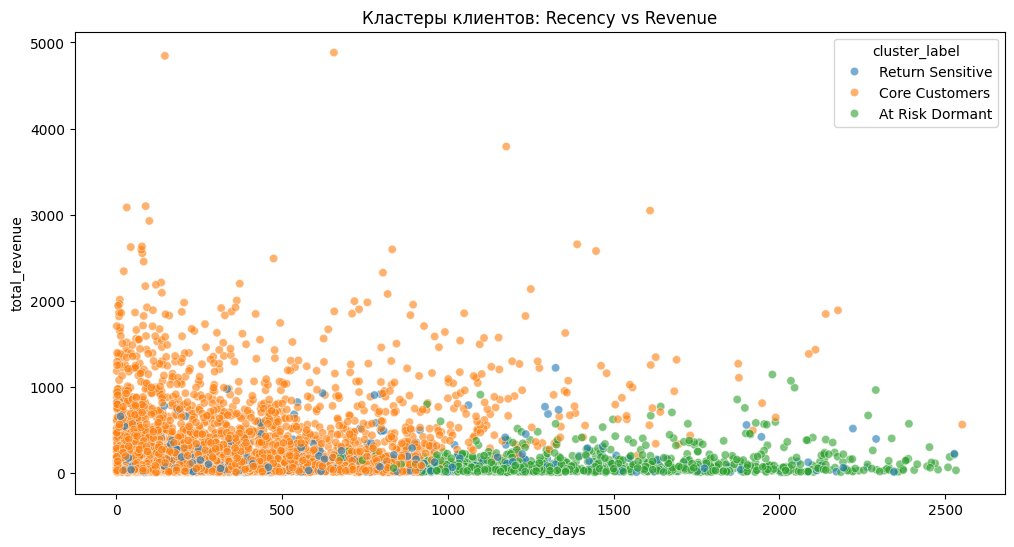

In [124]:
# Интерпретация кластеров для бизнеса.
cluster_summary = customer_cluster_mart.groupby('cluster', as_index=False).agg(
    users_cnt=('user_id', 'count'),
    avg_revenue=('total_revenue', 'mean'),
    avg_orders=('orders_cnt', 'mean'),
    avg_recency=('recency_days', 'mean'),
    avg_return_rate=('return_rate', 'mean'),
    avg_delivery_days=('avg_delivery_days', 'mean'),
    avg_events=('events_cnt', 'mean')
)

def label_cluster(row):
    if row['avg_revenue'] >= customer_cluster_mart['total_revenue'].mean() and row['avg_recency'] <= customer_cluster_mart['recency_days'].median():
        return 'High Value Active'
    if row['avg_return_rate'] >= customer_cluster_mart['return_rate'].mean() * 1.1:
        return 'Return Sensitive'
    if row['avg_events'] >= customer_cluster_mart['events_cnt'].fillna(0).mean() and row['avg_orders'] <= customer_cluster_mart['orders_cnt'].mean():
        return 'Engaged Browsers'
    if row['avg_recency'] >= customer_cluster_mart['recency_days'].mean() * 1.1:
        return 'At Risk Dormant'
    return 'Core Customers'

cluster_summary['cluster_label'] = cluster_summary.apply(label_cluster, axis=1)
customer_cluster_mart = customer_cluster_mart.merge(cluster_summary[['cluster', 'cluster_label']], on='cluster', how='left')

display(cluster_summary.sort_values('users_cnt', ascending=False))

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=customer_cluster_mart.sample(min(5000, len(customer_cluster_mart)), random_state=42),
    x='recency_days', y='total_revenue', hue='cluster_label', alpha=0.6
)
plt.title('Кластеры клиентов: Recency vs Revenue')
plt.show()


In [126]:
# Quality score товаров и категорий.
product_quality_base = orders_eda.copy()

required_review_cols = [
    'review_text',
    'review_word_count',
    'review_negative_flag',
    'review_positive_flag',
    'review_sentiment_score'
]

if not set(required_review_cols).issubset(product_quality_base.columns):
    positive_words_local = {
        'good', 'great', 'excellent', 'amazing', 'perfect', 'love', 'loved', 'happy',
        'comfortable', 'durable', 'nice', 'solid', 'recommend', 'satisfied', 'works'
    }
    negative_words_local = {
        'bad', 'poor', 'terrible', 'awful', 'disappointed', 'broken', 'late', 'return',
        'cheap', 'worst', 'hate', 'problem', 'issue', 'damaged', 'small', 'big', 'fit'
    }

    product_quality_base['review_text'] = product_quality_base['customer_review'].fillna('Unknown').astype(str)
    product_quality_base['review_text_clean_tmp'] = (
        product_quality_base['review_text']
        .str.lower()
        .str.replace(r'[^a-z\s]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    product_quality_base['review_word_count'] = product_quality_base['review_text_clean_tmp'].str.split().str.len()
    product_quality_base['positive_word_count_tmp'] = product_quality_base['review_text_clean_tmp'].apply(
        lambda x: sum(token in positive_words_local for token in x.split())
    )
    product_quality_base['negative_word_count_tmp'] = product_quality_base['review_text_clean_tmp'].apply(
        lambda x: sum(token in negative_words_local for token in x.split())
    )
    product_quality_base['review_sentiment_score'] = (
        product_quality_base['positive_word_count_tmp'] - product_quality_base['negative_word_count_tmp']
    )
    product_quality_base['review_negative_flag'] = (
        product_quality_base['negative_word_count_tmp'] > product_quality_base['positive_word_count_tmp']
    ).astype(int)
    product_quality_base['review_positive_flag'] = (
        product_quality_base['positive_word_count_tmp'] > product_quality_base['negative_word_count_tmp']
    ).astype(int)

product_quality_mart = product_quality_base.groupby(
    ['product_id', 'product_name', 'category'], as_index=False
).agg(
    review_count=('review_text', 'count'),
    revenue=('line_revenue', 'sum'),
    orders_cnt=('order_id', 'nunique'),
    return_rate=('is_returned', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_margin_ratio=('margin_ratio', 'mean'),
    negative_review_rate=('review_negative_flag', 'mean'),
    positive_review_rate=('review_positive_flag', 'mean'),
    avg_sentiment_score=('review_sentiment_score', 'mean')
)

product_quality_mart['delivery_risk_component'] = (
    product_quality_mart['avg_delivery_days']
    .fillna(product_quality_mart['avg_delivery_days'].median())
)
product_quality_mart['delivery_risk_component'] = (
    product_quality_mart['delivery_risk_component'] /
    product_quality_mart['delivery_risk_component'].max()
)

product_quality_mart['quality_risk_score'] = (
    0.45 * product_quality_mart['return_rate'].fillna(0) +
    0.35 * product_quality_mart['negative_review_rate'].fillna(0) +
    0.20 * product_quality_mart['delivery_risk_component'].fillna(0)
)

product_quality_mart['quality_label'] = pd.cut(
    product_quality_mart['quality_risk_score'],
    bins=[-np.inf, 0.08, 0.16, np.inf],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

product_quality_mart['exclude_from_reco'] = (
    (product_quality_mart['quality_label'] == 'High Risk') &
    (product_quality_mart['orders_cnt'] >= 10)
).astype(int)

display(product_quality_mart.sort_values('quality_risk_score', ascending=False).head(20))


,product_id,product_name,category,review_count,revenue,orders_cnt,return_rate,avg_delivery_days,avg_margin_ratio,negative_review_rate,positive_review_rate,avg_sentiment_score,delivery_risk_component,quality_risk_score,quality_label,exclude_from_reco
10435,10484,Goddess Women's Keira Nursing Bra,Intimates,1,48.000000,1,1.0,7.883333,0.442,1.0,0.0,-1.0,0.987904,0.997581,High Risk,0
15145,15208,Paige Maternity Jeans : Union Laurel Canyon - ...,Maternity,1,194.000000,1,1.0,7.324306,0.555,1.0,0.0,-1.0,0.917849,0.983570,High Risk,0
2601,2613,Helly Hansen Women's Voss Pant,Active,1,30.000000,1,1.0,6.771528,0.583,1.0,0.0,-1.0,0.848577,0.969715,High Risk,0
11275,11327,Kendall Scoop Strappy Tank by Yummie Tummie #Y...,Intimates,1,113.419998,1,1.0,6.745833,0.492,1.0,0.0,-1.0,0.845357,0.969071,High Risk,0
7656,7692,G-Star Women's Cruise Blazer,Blazers & Jackets,1,122.570000,1,1.0,6.731250,0.608,1.0,0.0,-1.0,0.843530,0.968706,High Risk,0
25267,25345,Darn Tough - 1/4 Sock Merino Mesh,Socks,1,34.000000,1,1.0,6.224306,0.401,1.0,0.0,-1.0,0.780002,0.956000,High Risk,0
14029,14088,Eco-Friendly Premium Silky Soft Bamboo Fiber S...,Accessories,1,35.969999,1,1.0,6.108333,0.647,1.0,0.0,-1.0,0.765469,0.953094,High Risk,0
8188,8227,KASPER Subtle Chic 3PC Jacket/Pants/Cami Suit-...,Suits,1,122.820000,1,1.0,6.082639,0.401,1.0,0.0,-1.0,0.762249,0.952450,High Risk,0
7687,7724,Mango Women's Biker BouclÃ© Jacket - Flu,Blazers & Jackets,1,239.960007,1,1.0,5.840972,0.652,1.0,0.0,-1.0,0.731964,0.946393,High Risk,0
17412,17479,Fox Men's Spliced Up Pullover Hoody,Fashion Hoodies & Sweatshirts,1,198.000000,1,1.0,5.580556,0.487,1.0,0.0,-1.0,0.699330,0.939866,High Risk,0


,category,products_cnt,revenue,avg_return_rate,avg_negative_review_rate,avg_sentiment_score,avg_quality_risk_score,excluded_products_cnt
21,Suits & Sport Coats,739,1.256122e+06,0.105703,0.128310,1.030023,0.193699,80
12,Pants,1041,8.143265e+05,0.094956,0.143358,0.874118,0.192765,110
7,Jeans,1994,2.383560e+06,0.096867,0.138098,0.901557,0.192552,171
13,Pants & Capris,609,3.828363e+05,0.108091,0.117894,1.038142,0.190998,28
2,Blazers & Jackets,558,5.809921e+05,0.109892,0.115579,1.088665,0.189514,23
8,Jumpsuits & Rompers,162,7.742774e+04,0.110908,0.112451,1.071717,0.189168,6
17,Sleep & Lounge,1769,1.070311e+06,0.103996,0.111085,1.053015,0.186542,134
25,Underwear,1087,3.998194e+05,0.103634,0.114836,1.037792,0.185695,120
18,Socks,901,2.352262e+05,0.101376,0.104306,1.079617,0.183380,98
19,Socks & Hosiery,660,1.183422e+05,0.107072,0.100427,1.159439,0.183060,25


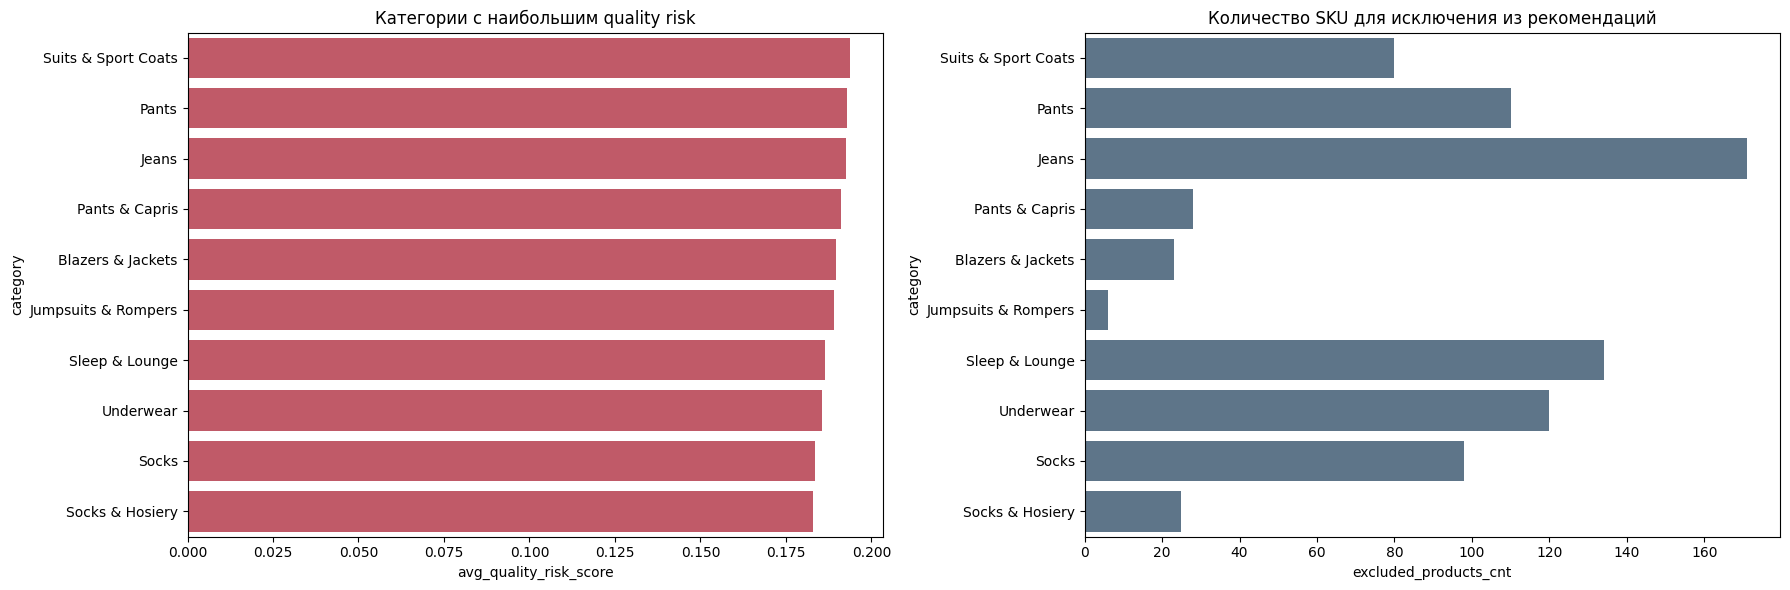

In [127]:
# Категории с наибольшим уровнем недовольства.
category_quality_mart = product_quality_mart.groupby('category', as_index=False).agg(
    products_cnt=('product_id', 'nunique'),
    revenue=('revenue', 'sum'),
    avg_return_rate=('return_rate', 'mean'),
    avg_negative_review_rate=('negative_review_rate', 'mean'),
    avg_sentiment_score=('avg_sentiment_score', 'mean'),
    avg_quality_risk_score=('quality_risk_score', 'mean'),
    excluded_products_cnt=('exclude_from_reco', 'sum')
).sort_values('avg_quality_risk_score', ascending=False)

display(category_quality_mart.head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=category_quality_mart.head(10), y='category', x='avg_quality_risk_score', ax=axes[0], color='#D1495B')
axes[0].set_title('Категории с наибольшим quality risk')

sns.barplot(data=category_quality_mart.head(10), y='category', x='excluded_products_cnt', ax=axes[1], color='#577590')
axes[1].set_title('Количество SKU для исключения из рекомендаций')

plt.tight_layout()
plt.show()


RFM и ABC/XYZ

In [128]:
# RFM-сегментация клиентов.
snapshot_date_rfm = orders_eda['created_at'].max() + pd.Timedelta(days=1)

rfm_mart = orders_eda.groupby('user_id', as_index=False).agg(
    last_purchase_at=('created_at', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('line_revenue', 'sum')
)

rfm_mart['recency'] = (snapshot_date_rfm - rfm_mart['last_purchase_at']).dt.days

rfm_mart['r_score'] = pd.qcut(
    rfm_mart['recency'].rank(method='first', ascending=False),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)
rfm_mart['f_score'] = pd.qcut(
    rfm_mart['frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)
rfm_mart['m_score'] = pd.qcut(
    rfm_mart['monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_mart['rfm_score'] = rfm_mart[['r_score', 'f_score', 'm_score']].astype(str).agg(''.join, axis=1)

def label_rfm_segment(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4 and row['m_score'] >= 4:
        return 'Champions'
    if row['r_score'] >= 3 and row['f_score'] >= 4:
        return 'Loyal Customers'
    if row['r_score'] >= 4 and row['f_score'] <= 2:
        return 'Potential Loyalists'
    if row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'At Risk'
    if row['r_score'] <= 2 and row['f_score'] <= 2:
        return 'Hibernating'
    return 'Regular'

rfm_mart['rfm_segment'] = rfm_mart.apply(label_rfm_segment, axis=1)

display(rfm_mart.head())
display(rfm_mart['rfm_segment'].value_counts().to_frame('users_cnt'))


,user_id,last_purchase_at,frequency,monetary,recency,r_score,f_score,m_score,rfm_score,rfm_segment
0,1,2024-10-14 10:31:40+00:00,1,55.490002,513,2,1,2,212,Hibernating
1,2,2025-04-11 13:43:06+00:00,2,343.000000,334,3,4,4,344,Loyal Customers
2,3,2022-09-05 21:23:16+00:00,1,103.980000,1283,1,1,3,113,Hibernating
3,4,2026-02-28 07:34:44+00:00,1,22.500000,11,5,1,1,511,Potential Loyalists
4,6,2024-03-04 09:47:17+00:00,1,6.740000,737,2,1,1,211,Hibernating


,users_cnt
rfm_segment,
At Risk,16812
Hibernating,15197
Regular,14509
Loyal Customers,12499
Potential Loyalists,10625
Champions,10379


,rfm_segment,users_cnt,avg_recency,avg_frequency,avg_monetary
0,At Risk,16812,1030.278075,1.641209,269.389261
2,Hibernating,15197,1134.168849,1.000000,165.636199
5,Regular,14509,269.294093,1.000000,166.739416
3,Loyal Customers,12499,241.209457,2.272502,255.594765
4,Potential Loyalists,10625,98.709553,1.000000,161.678135
1,Champions,10379,90.060796,2.770787,599.069130


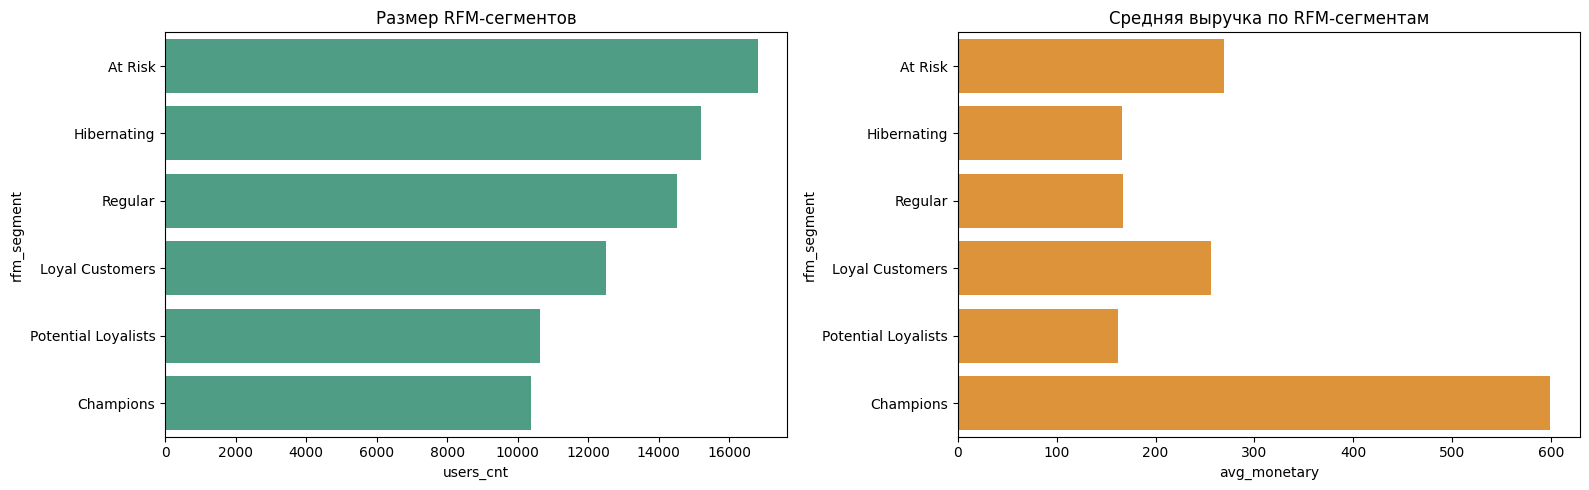

In [129]:
# Визуализация RFM-сегментов.
rfm_segment_summary = rfm_mart.groupby('rfm_segment', as_index=False).agg(
    users_cnt=('user_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).sort_values('users_cnt', ascending=False)

display(rfm_segment_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=rfm_segment_summary, y='rfm_segment', x='users_cnt', ax=axes[0], color='#43AA8B')
axes[0].set_title('Размер RFM-сегментов')

sns.barplot(data=rfm_segment_summary, y='rfm_segment', x='avg_monetary', ax=axes[1], color='#F8961E')
axes[1].set_title('Средняя выручка по RFM-сегментам')

plt.tight_layout()
plt.show()


In [130]:
# ABC/XYZ-анализ товаров.
product_monthly_sales = orders_eda.groupby(['product_id', 'product_name', 'category', 'order_month'], as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    orders_cnt=('order_id', 'nunique')
)

abc_xyz_mart = product_monthly_sales.groupby(['product_id', 'product_name', 'category'], as_index=False).agg(
    total_revenue=('revenue', 'sum'),
    avg_monthly_revenue=('revenue', 'mean'),
    std_monthly_revenue=('revenue', 'std'),
    months_active=('order_month', 'nunique')
)

abc_xyz_mart['std_monthly_revenue'] = abc_xyz_mart['std_monthly_revenue'].fillna(0)
abc_xyz_mart['cv'] = np.where(
    abc_xyz_mart['avg_monthly_revenue'] > 0,
    abc_xyz_mart['std_monthly_revenue'] / abc_xyz_mart['avg_monthly_revenue'],
    0
)

abc_xyz_mart = abc_xyz_mart.sort_values('total_revenue', ascending=False)
abc_xyz_mart['cum_share'] = abc_xyz_mart['total_revenue'].cumsum() / abc_xyz_mart['total_revenue'].sum()

abc_xyz_mart['abc_class'] = np.select(
    [abc_xyz_mart['cum_share'] <= 0.80, abc_xyz_mart['cum_share'] <= 0.95],
    ['A', 'B'],
    default='C'
)

abc_xyz_mart['xyz_class'] = np.select(
    [abc_xyz_mart['cv'] <= 0.10, abc_xyz_mart['cv'] <= 0.25],
    ['X', 'Y'],
    default='Z'
)

abc_xyz_mart['abc_xyz_segment'] = abc_xyz_mart['abc_class'] + abc_xyz_mart['xyz_class']

display(abc_xyz_mart.head(20))
display(abc_xyz_mart['abc_xyz_segment'].value_counts().to_frame('products_cnt'))


,product_id,product_name,category,total_revenue,avg_monthly_revenue,std_monthly_revenue,months_active,cv,cum_share,abc_class,xyz_class,abc_xyz_segment
23914,23989,The North Face Freedom Mens Ski Pants 2013,Outerwear & Coats,24381.0,2438.100000,956.592965,10,0.392352,0.001184,A,Z,AZ
24372,24447,Darla,Outerwear & Coats,17982.0,1798.200000,918.017647,10,0.510520,0.002057,A,Z,AZ
22738,22812,Quiksilver Men's Rockefeller Walkshort,Shorts,17157.0,1906.333333,951.845576,9,0.499307,0.002890,A,Z,AZ
18588,18656,JORDAN DURASHEEN SHORT MENS 404309-109,Active,17157.0,2859.500000,2091.895863,6,0.731560,0.003723,A,Z,AZ
8389,8429,The North Face Women's S-XL Oso Jacket,Outerwear & Coats,16254.0,2031.750000,1157.411120,8,0.569662,0.004512,A,Z,AZ
24353,24428,The North Face Apex Bionic Mens Soft Shell Ski...,Outerwear & Coats,16254.0,1625.400000,712.296006,10,0.438228,0.005301,A,Z,AZ
23978,24053,The North Face Denali Down Mens Jacket 2013,Outerwear & Coats,15351.0,1918.875000,1125.520380,8,0.586552,0.006047,A,Z,AZ
5190,5213,Catherine Malandrino Women's Skinny Stretch Le...,Pants & Capris,15215.0,2535.833333,1046.295449,6,0.412604,0.006785,A,Z,AZ
23579,23654,The North Face Apex Bionic Soft Shell Jacket -...,Outerwear & Coats,14448.0,2064.000000,1004.765644,7,0.486805,0.007487,A,Z,AZ
23471,23546,Alpha Industries Rip Stop Short,Shorts,13986.0,2331.000000,1364.893842,6,0.585540,0.008166,A,Z,AZ


,products_cnt
abc_xyz_segment,
AZ,12428
BZ,8311
CZ,6354
CX,1122
BX,249
AY,173
BY,152
CY,130
AX,120


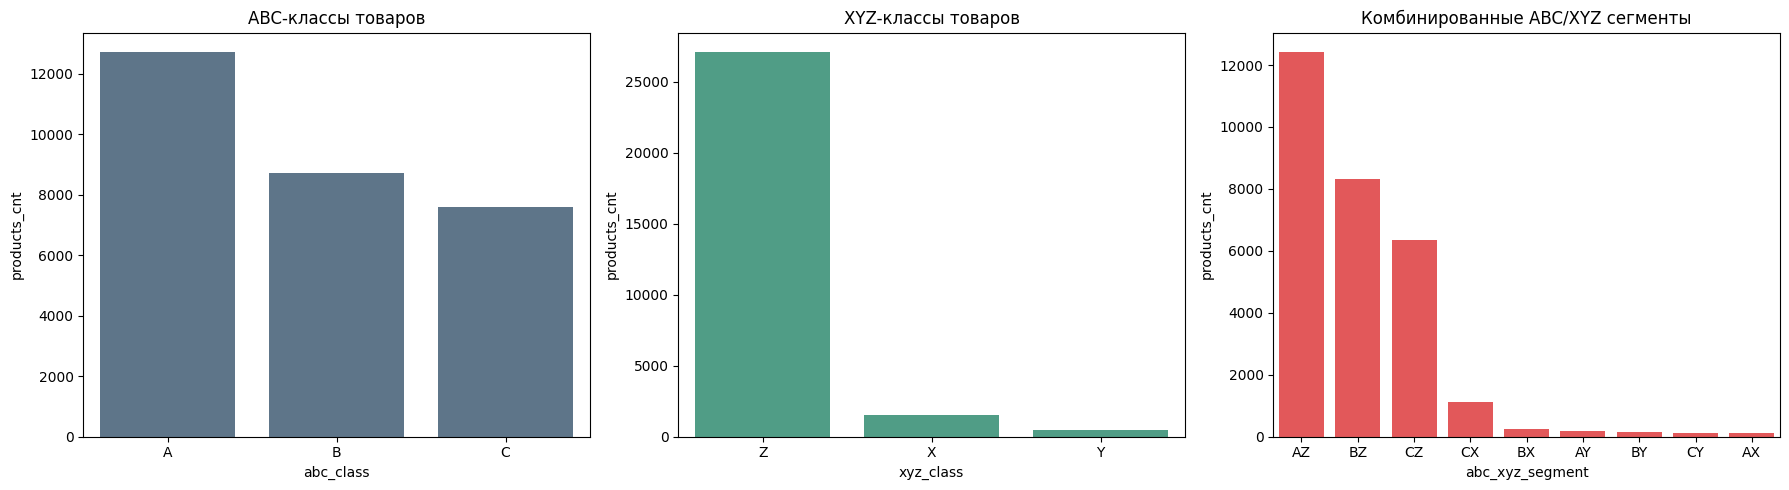

In [131]:
# Визуализация ABC/XYZ.
abc_summary = abc_xyz_mart['abc_class'].value_counts().rename_axis('abc_class').reset_index(name='products_cnt')
xyz_summary = abc_xyz_mart['xyz_class'].value_counts().rename_axis('xyz_class').reset_index(name='products_cnt')
abc_xyz_summary = abc_xyz_mart['abc_xyz_segment'].value_counts().rename_axis('abc_xyz_segment').reset_index(name='products_cnt')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=abc_summary, x='abc_class', y='products_cnt', ax=axes[0], color='#577590')
axes[0].set_title('ABC-классы товаров')

sns.barplot(data=xyz_summary, x='xyz_class', y='products_cnt', ax=axes[1], color='#43AA8B')
axes[1].set_title('XYZ-классы товаров')

sns.barplot(data=abc_xyz_summary.head(9), x='abc_xyz_segment', y='products_cnt', ax=axes[2], color='#F94144')
axes[2].set_title('Комбинированные ABC/XYZ сегменты')

plt.tight_layout()
plt.show()


Прогнозирование

In [138]:
# Подготовка ряда для прогнозирования продаж.
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sales_forecast_df = daily_sales.copy()
sales_forecast_df['order_date'] = pd.to_datetime(sales_forecast_df['order_date'])
sales_forecast_df = sales_forecast_df.sort_values('order_date').reset_index(drop=True)

sales_forecast_df['day_of_week_num'] = sales_forecast_df['order_date'].dt.dayofweek
sales_forecast_df['month_num'] = sales_forecast_df['order_date'].dt.month
sales_forecast_df['week_num'] = sales_forecast_df['order_date'].dt.isocalendar().week.astype(int)
sales_forecast_df['is_weekend'] = sales_forecast_df['day_of_week_num'].isin([5, 6]).astype(int)
sales_forecast_df['day_of_month'] = sales_forecast_df['order_date'].dt.day
sales_forecast_df['time_idx'] = np.arange(len(sales_forecast_df))
sales_forecast_df['revenue_log'] = np.log1p(sales_forecast_df['revenue'])

target_cols = ['revenue', 'orders_cnt', 'revenue_log']
display(sales_forecast_df.head())
print('sales_forecast_df shape:', sales_forecast_df.shape)


,order_date,revenue,profit,orders_cnt,users_cnt,items_cnt,day_of_week_num,month_num,week_num,is_weekend,day_of_month,time_idx,revenue_log
0,2019-01-04,22.889999,10.025820,1,1,1,4,1,1,0,4,0,3.173460
1,2019-01-10,572.719994,306.745836,1,1,16,3,1,2,0,10,1,6.352141
2,2019-01-16,39.990002,20.154961,1,1,1,2,1,3,0,16,2,3.713328
3,2019-01-18,149.820000,86.048300,1,1,4,4,1,3,0,18,3,5.016087
4,2019-01-20,1091.959999,654.224277,1,1,16,6,1,3,1,20,4,6.996645


sales_forecast_df shape: (2571, 13)


In [139]:
# Лаговые и rolling-признаки.
for target in target_cols:
    for lag in [1, 7, 14, 28]:
        sales_forecast_df[f'{target}_lag_{lag}'] = sales_forecast_df[target].shift(lag)

    for window in [7, 14, 28]:
        sales_forecast_df[f'{target}_roll_mean_{window}'] = sales_forecast_df[target].shift(1).rolling(window).mean()
        sales_forecast_df[f'{target}_roll_std_{window}'] = sales_forecast_df[target].shift(1).rolling(window).std()

sales_forecast_model_df = sales_forecast_df.dropna().copy()
print('sales_forecast_model_df shape:', sales_forecast_model_df.shape)
display(sales_forecast_model_df.head())


sales_forecast_model_df shape: (2543, 43)


,order_date,revenue,profit,orders_cnt,users_cnt,items_cnt,day_of_week_num,month_num,week_num,is_weekend,...,revenue_log_lag_1,revenue_log_lag_7,revenue_log_lag_14,revenue_log_lag_28,revenue_log_roll_mean_7,revenue_log_roll_std_7,revenue_log_roll_mean_14,revenue_log_roll_std_14,revenue_log_roll_mean_28,revenue_log_roll_std_28
28,2019-03-05,1167.920006,634.366762,1,1,16,1,3,10,0,...,4.369448,6.378341,3.496204,3.173460,4.986799,1.646620,4.843198,1.353254,4.839768,1.456951
29,2019-03-08,209.000000,104.082000,1,1,1,4,3,10,0,...,7.063836,5.870596,5.720312,6.352141,5.084726,1.759674,5.098029,1.414609,4.978710,1.477516
30,2019-03-09,94.980003,47.919322,2,2,2,5,3,10,1,...,5.347108,4.948476,3.950667,3.713328,5.009942,1.731609,5.071371,1.405468,4.942816,1.454950
31,2019-03-10,25.000000,10.625000,1,1,1,6,3,10,1,...,4.564140,7.190269,5.078543,5.016087,4.955037,1.739956,5.115191,1.377116,4.973202,1.437096
32,2019-03-11,216.950001,88.640100,3,3,3,0,3,11,0,...,3.258097,2.366498,5.247024,6.996645,4.393298,1.518726,4.985159,1.464045,4.910417,1.473105


In [140]:
# Time-based split для прогноза выручки.
forecast_feature_cols = [
    col for col in sales_forecast_model_df.columns
    if col not in ['order_date', 'revenue', 'revenue_log', 'profit', 'orders_cnt', 'users_cnt', 'items_cnt']
]

forecast_cutoff = sales_forecast_model_df['order_date'].quantile(0.85)
train_forecast_df = sales_forecast_model_df[sales_forecast_model_df['order_date'] <= forecast_cutoff].copy()
valid_forecast_df = sales_forecast_model_df[sales_forecast_model_df['order_date'] > forecast_cutoff].copy()

X_train_forecast = train_forecast_df[forecast_feature_cols].copy()
X_valid_forecast = valid_forecast_df[forecast_feature_cols].copy()

y_train_revenue = train_forecast_df['revenue'].copy()
y_valid_revenue = valid_forecast_df['revenue'].copy()
y_train_revenue_log = train_forecast_df['revenue_log'].copy()
y_valid_revenue_log = valid_forecast_df['revenue_log'].copy()

print('train_forecast_df:', train_forecast_df.shape)
print('valid_forecast_df:', valid_forecast_df.shape)
print('forecast features:', len(forecast_feature_cols))

train_forecast_df: (2161, 43)
valid_forecast_df: (382, 43)
forecast features: 36


In [141]:
# Модель прогноза выручки в log-шкале.
revenue_forecast_model = CatBoostRegressor(
    iterations=600,
    depth=6,
    learning_rate=0.04,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=False
)

revenue_forecast_model.fit(X_train_forecast, y_train_revenue_log)
revenue_pred_log = revenue_forecast_model.predict(X_valid_forecast)
revenue_pred = np.expm1(revenue_pred_log)
revenue_pred = np.clip(revenue_pred, a_min=0, a_max=None)

revenue_mae = mean_absolute_error(y_valid_revenue, revenue_pred)
revenue_rmse = mean_squared_error(y_valid_revenue, revenue_pred) ** 0.5
revenue_wape = np.abs(y_valid_revenue - revenue_pred).sum() / np.abs(y_valid_revenue).sum()

print('Revenue forecast MAE :', round(revenue_mae, 2))
print('Revenue forecast RMSE:', round(revenue_rmse, 2))
print('Revenue forecast WAPE:', round(revenue_wape, 4))

forecast_importance = pd.DataFrame({
    'feature': X_train_forecast.columns,
    'importance': revenue_forecast_model.get_feature_importance()
}).sort_values('importance', ascending=False)
display(forecast_importance.head(20))

Revenue forecast MAE : 10922.74
Revenue forecast RMSE: 22674.14
Revenue forecast WAPE: 0.4607


,feature,importance
24,orders_cnt_roll_mean_28,5.527567
14,revenue_roll_mean_28,5.368113
18,orders_cnt_lag_14,5.183234
5,time_idx,4.906858
25,orders_cnt_roll_std_28,3.982183
31,revenue_log_roll_std_7,3.869632
11,revenue_roll_std_7,3.584127
17,orders_cnt_lag_7,3.459888
30,revenue_log_roll_mean_7,3.336202
32,revenue_log_roll_mean_14,3.300320


,order_date,revenue,orders_cnt,revenue_log,revenue_pred_log,revenue_pred,abs_error
2189,2025-02-23,11155.970000,92,9.319820,9.481630,13115.553255,1959.583255
2190,2025-02-24,5952.990008,74,8.691817,9.542604,13940.198571,7987.208563
2191,2025-02-25,18128.799997,94,9.805312,9.531795,13790.320419,4338.479578
2192,2025-02-26,14275.100037,75,9.566342,9.533995,13820.697465,454.402571
2193,2025-02-27,13869.520016,109,9.537521,9.435235,12520.906537,1348.613479
2194,2025-02-28,21989.190125,103,9.998352,9.472983,13002.622039,8986.568086
2195,2025-03-01,16517.430000,93,9.712232,9.495460,13298.204929,3219.225071
2196,2025-03-02,15725.120108,74,9.663078,9.469747,12960.607953,2764.512155
2197,2025-03-03,20632.360085,98,9.934664,9.387473,11936.893358,8695.466728
2198,2025-03-04,13072.030004,94,9.478307,9.478779,13078.202263,6.172260


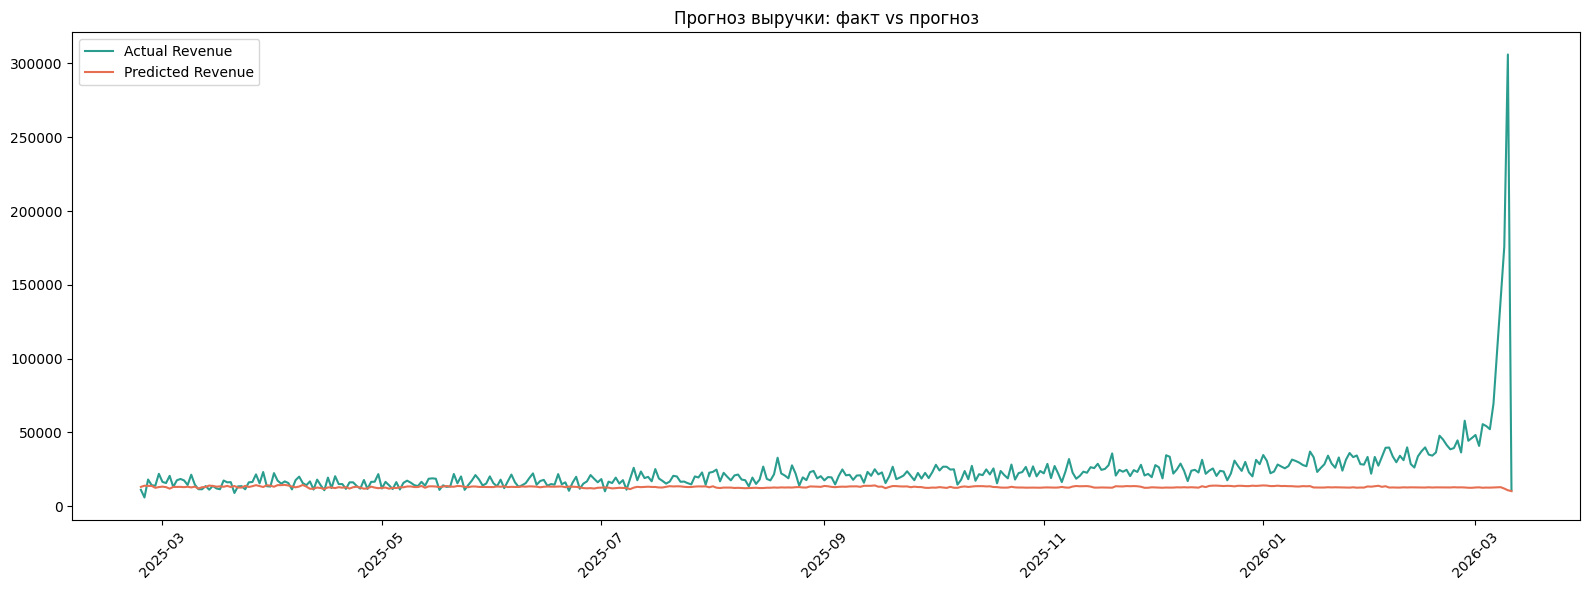

In [142]:
# Визуализация факта и прогноза.
revenue_forecast_result = valid_forecast_df[['order_date', 'revenue', 'orders_cnt', 'revenue_log']].copy()
revenue_forecast_result['revenue_pred_log'] = revenue_pred_log
revenue_forecast_result['revenue_pred'] = revenue_pred
revenue_forecast_result['abs_error'] = (revenue_forecast_result['revenue'] - revenue_forecast_result['revenue_pred']).abs()

display(revenue_forecast_result.head(20))

plt.figure(figsize=(16, 6))
plt.plot(revenue_forecast_result['order_date'], revenue_forecast_result['revenue'], label='Actual Revenue', color='#2A9D8F')
plt.plot(revenue_forecast_result['order_date'], revenue_forecast_result['revenue_pred'], label='Predicted Revenue', color='#E76F51')
plt.title('Прогноз выручки: факт vs прогноз')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [143]:
# Прогноз количества заказов.
y_train_orders = train_forecast_df['orders_cnt'].copy()
y_valid_orders = valid_forecast_df['orders_cnt'].copy()

orders_forecast_model = CatBoostRegressor(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=False
)

orders_forecast_model.fit(X_train_forecast, y_train_orders)
orders_pred = orders_forecast_model.predict(X_valid_forecast)

orders_mae = mean_absolute_error(y_valid_orders, orders_pred)
orders_rmse = mean_squared_error(y_valid_orders, orders_pred) ** 0.5
orders_wape = np.abs(y_valid_orders - orders_pred).sum() / np.abs(y_valid_orders).sum()

print('Orders forecast MAE :', round(orders_mae, 2))
print('Orders forecast RMSE:', round(orders_rmse, 2))
print('Orders forecast WAPE:', round(orders_wape, 4))


Orders forecast MAE : 64.54
Orders forecast RMSE: 132.01
Orders forecast WAPE: 0.448
